In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

In [3]:
df=pd.read_csv('/content/drive/MyDrive/Capstone Project Code/sleep_data_updated (3) (1) (1).csv')

In [4]:
df

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6.0,42,6,Overweight,126/83,77,4200,No disease
1,Male,28,Doctor,6.2,6.0,60,8,Normal,125/80,75,10000,No disease
2,Male,28,Doctor,6.2,6.0,60,8,Normal,125/80,75,10000,No disease
3,Male,28,Sales Representative,5.9,4.0,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4.0,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...
769,Female,36,Student,4.5,7.9,73,7,Normal,118/66,64,14497,Sleep Apnea
770,Female,45,Manual Labor,6.0,6.1,72,8,Obese,132/80,65,12848,Insomnia
771,Female,30,Student,5.3,6.5,58,10,Obese,125/76,66,15255,Insomnia
772,Female,41,Retired,11.0,9.1,73,9,Obese,130/75,75,6567,Sleep Apnea


**Null value check**

In [5]:
df.isnull().sum()

,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0
Heart Rate,0


**Find out dublicate value.**

In [6]:
df.duplicated().sum()


np.int64(242)

**Drop the dublicate value.**

In [7]:
df = df.drop_duplicates()


**Here we know about the dataset after dublicate,null value handling.**

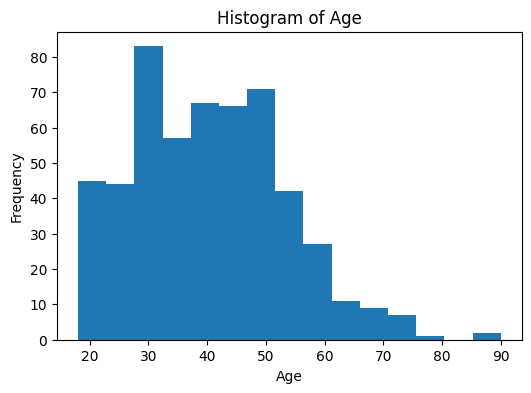

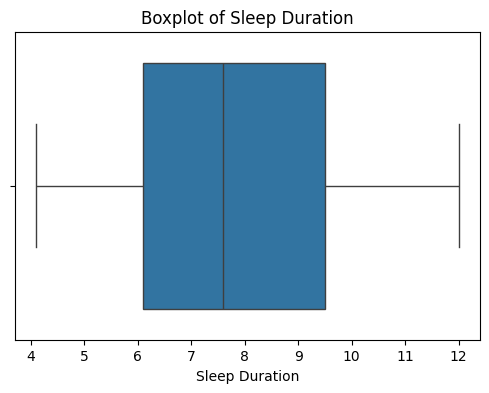

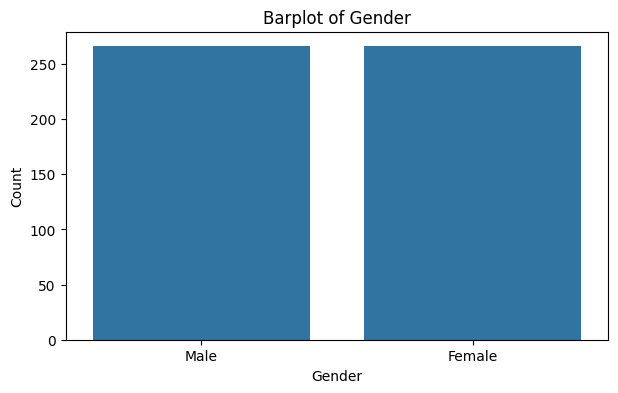

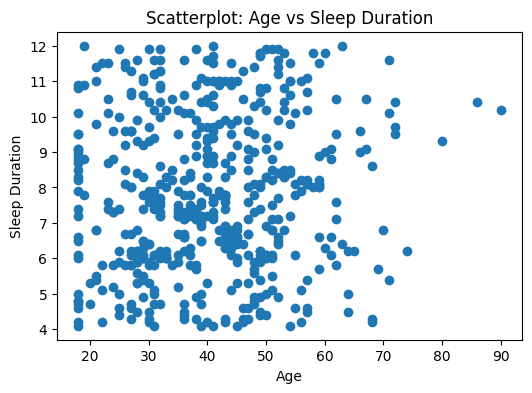

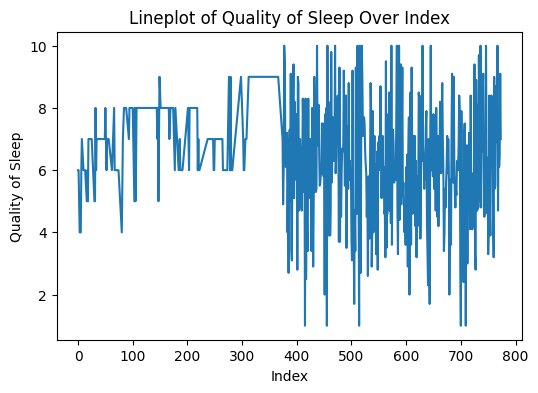

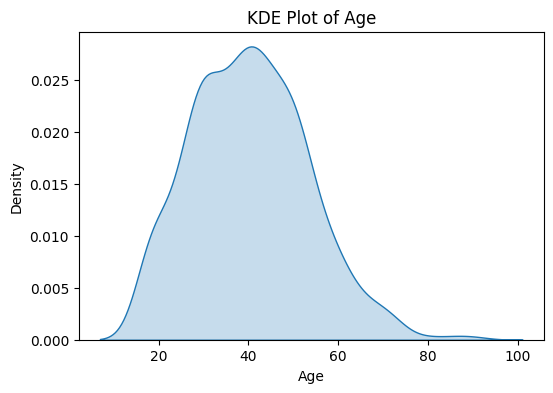

In [8]:
# 1️⃣ HISTOGRAM (First Numeric Column)
# ============================
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
if len(num_cols) > 0:
    plt.figure(figsize=(6,4))
    plt.hist(df[num_cols[0]], bins=15)
    plt.title(f"Histogram of {num_cols[0]}")
    plt.xlabel(num_cols[0])
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No numeric column available for histogram.")

# ============================
# 2️⃣ BOXPLOT (Second Numeric Column)
# ============================
if len(num_cols) > 1:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[num_cols[1]])
    plt.title(f"Boxplot of {num_cols[1]}")
    plt.xlabel(num_cols[1])
    plt.show()
else:
    print("Not enough numeric columns for boxplot.")

# ============================
# 3️⃣ BARPLOT (First Categorical Column)
# ============================
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=cat_cols[0])
    plt.title(f"Barplot of {cat_cols[0]}")
    plt.xlabel(cat_cols[0])
    plt.ylabel("Count")
    plt.show()
else:
    print("No categorical column for barplot.")

# ============================
# 4️⃣ SCATTERPLOT (Two Numeric Columns)
# ============================
if len(num_cols) > 1:
    plt.figure(figsize=(6,4))
    plt.scatter(df[num_cols[0]], df[num_cols[1]])
    plt.title(f"Scatterplot: {num_cols[0]} vs {num_cols[1]}")
    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])
    plt.show()
else:
    print("Not enough numeric columns for scatterplot.")

# ============================
# 5️⃣ LINEPLOT (Third Numeric Column if exists)
# ============================
if len(num_cols) > 2:
    plt.figure(figsize=(6,4))
    sns.lineplot(x=df.index, y=df[num_cols[2]])
    plt.title(f"Lineplot of {num_cols[2]} Over Index")
    plt.xlabel("Index")
    plt.ylabel(num_cols[2])
    plt.show()
else:
    print("Not enough numeric columns for lineplot.")

# ============================
# 6️⃣ KDE PLOT (Any Numeric Column)
# ============================
if len(num_cols) > 0:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[num_cols[0]], fill=True)
    plt.title(f"KDE Plot of {num_cols[0]}")
    plt.xlabel(num_cols[0])
    plt.show()
else:
    print("No numeric column for KDE plot.")

**Target column value count after dublicate value drop for particular class.And it's check for dataset balanced or imbalanced.**

In [9]:
df["Sleep Disorder"].value_counts()


,count
Sleep Disorder,
No disease,363
Insomnia,108
Sleep Apnea,61


**And showing percentage of the target column.**

In [10]:
df["Sleep Disorder"].value_counts(normalize=True) * 100


,proportion
Sleep Disorder,
No disease,68.233083
Insomnia,20.300752
Sleep Apnea,11.466165


**Showing ber plot the targert column.**

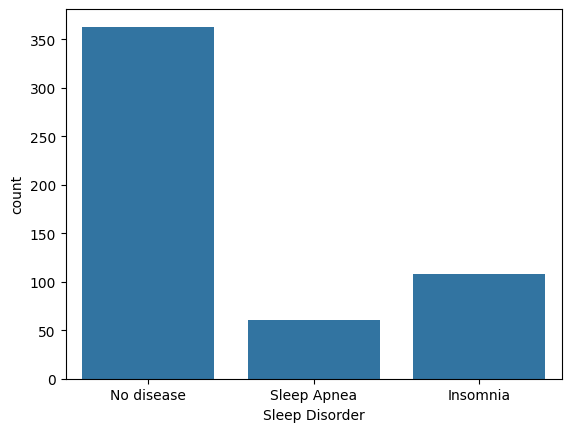

In [11]:
sns.countplot(x=df["Sleep Disorder"])
plt.show()


In [12]:
df.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000
mean,40.242481,7.803383,6.380263,63.349624,5.488722,74.802632,9975.195489
std,12.942995,2.148268,1.878064,29.921900,2.583787,13.469941,5106.700889
min,18.000000,4.100000,1.000000,10.000000,1.000000,50.000000,2067.000000
25%,30.000000,6.100000,5.200000,38.750000,3.000000,65.000000,5904.000000
50%,40.000000,7.600000,6.350000,60.000000,5.000000,72.000000,8560.500000
75%,49.000000,9.500000,7.925000,90.000000,8.000000,86.000000,14517.750000
max,90.000000,12.000000,10.000000,120.000000,10.000000,100.000000,19958.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532 entries, 0 to 773
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   532 non-null    object 
 1   Age                      532 non-null    int64  
 2   Occupation               532 non-null    object 
 3   Sleep Duration           532 non-null    float64
 4   Quality of Sleep         532 non-null    float64
 5   Physical Activity Level  532 non-null    int64  
 6   Stress Level             532 non-null    int64  
 7   BMI Category             532 non-null    object 
 8   Blood Pressure           532 non-null    object 
 9   Heart Rate               532 non-null    int64  
 10  Daily Steps              532 non-null    int64  
 11  Sleep Disorder           532 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 54.0+ KB


In [14]:
df_c = df.copy()

In [15]:
find = df_c['Gender'].unique()
print(find.size)
print(find)

2
['Male' 'Female']


In [16]:
find = df_c['Occupation'].unique()
print(find.size)
print(find)

15
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager'
 'Manual Labor' 'Retired' 'Office Worker' 'Student']


In [17]:
find = df_c['BMI Category'].unique()
print(find.size)
print(find)

5
['Overweight' 'Normal' 'Obese' 'Normal Weight' 'Underweight']


In [18]:
find = df_c['Blood Pressure'].unique()
print(find.size)
print(find)

268
['126/83' '125/80' '140/90' '120/80' '132/87' '130/86' '117/76' '118/76'
 '128/85' '131/86' '128/84' '115/75' '135/88' '129/84' '130/85' '115/78'
 '119/77' '121/79' '125/82' '135/90' '122/80' '142/92' '140/95' '139/91'
 '118/75' '124/70' '122/70' '124/72' '133/78' '123/60' '121/70' '134/87'
 '112/63' '125/84' '138/92' '113/66' '137/90' '123/73' '126/81' '134/79'
 '128/78' '114/65' '113/65' '113/63' '129/75' '122/77' '132/86' '126/78'
 '120/77' '118/71' '140/86' '124/73' '111/60' '123/74' '118/67' '135/86'
 '123/72' '129/82' '113/76' '119/70' '126/69' '136/82' '131/77' '110/60'
 '121/71' '122/72' '123/77' '121/73' '120/67' '122/73' '124/77' '138/88'
 '137/84' '109/67' '112/74' '123/76' '123/80' '133/86' '145/96' '128/71'
 '127/76' '127/74' '125/81' '114/60' '118/69' '116/63' '120/76' '137/95'
 '109/60' '125/74' '109/64' '116/71' '128/73' '114/69' '125/72' '114/66'
 '131/78' '120/73' '115/66' '136/86' '124/80' '119/66' '121/74' '125/77'
 '114/77' '123/61' '126/73' '110/61' '117/69' '

In [19]:
find = df_c['Sleep Disorder'].unique()
print(find.size)
print(find)

3
['No disease' 'Sleep Apnea' 'Insomnia']


In [20]:
from sklearn.preprocessing import LabelEncoder

# Create encoder object
le = LabelEncoder()


In [21]:
df["Gender"] = le.fit_transform(df["Gender"])
print("Gender mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


/tmp/ipython-input-80253006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Gender"] = le.fit_transform(df["Gender"])


In [22]:
df["Occupation"] = le.fit_transform(df["Occupation"])
print("Occupation mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Occupation mapping: {'Accountant': np.int64(0), 'Doctor': np.int64(1), 'Engineer': np.int64(2), 'Lawyer': np.int64(3), 'Manager': np.int64(4), 'Manual Labor': np.int64(5), 'Nurse': np.int64(6), 'Office Worker': np.int64(7), 'Retired': np.int64(8), 'Sales Representative': np.int64(9), 'Salesperson': np.int64(10), 'Scientist': np.int64(11), 'Software Engineer': np.int64(12), 'Student': np.int64(13), 'Teacher': np.int64(14)}


/tmp/ipython-input-3945188551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Occupation"] = le.fit_transform(df["Occupation"])


In [23]:
df["BMI Category"] = le.fit_transform(df["BMI Category"])
print("BMI Category mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


BMI Category mapping: {'Normal': np.int64(0), 'Normal Weight': np.int64(1), 'Obese': np.int64(2), 'Overweight': np.int64(3), 'Underweight': np.int64(4)}


/tmp/ipython-input-3779772431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["BMI Category"] = le.fit_transform(df["BMI Category"])


In [24]:
df["Sleep Disorder"] = le.fit_transform(df["Sleep Disorder"])
print("Sleep Disorder mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Sleep Disorder mapping: {'Insomnia': np.int64(0), 'No disease': np.int64(1), 'Sleep Apnea': np.int64(2)}


/tmp/ipython-input-40778391.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sleep Disorder"] = le.fit_transform(df["Sleep Disorder"])


In [25]:
df[['Systolic', 'Diastolic']] = df["Blood Pressure"].str.split('/', expand=True)
df['Systolic'] = df['Systolic'].astype(int)
df['Diastolic'] = df['Diastolic'].astype(int)


/tmp/ipython-input-3167282237.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Systolic', 'Diastolic']] = df["Blood Pressure"].str.split('/', expand=True)
/tmp/ipython-input-3167282237.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Systolic', 'Diastolic']] = df["Blood Pressure"].str.split('/', expand=True)
/tmp/ipython-input-3167282237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532 entries, 0 to 773
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   532 non-null    int64  
 1   Age                      532 non-null    int64  
 2   Occupation               532 non-null    int64  
 3   Sleep Duration           532 non-null    float64
 4   Quality of Sleep         532 non-null    float64
 5   Physical Activity Level  532 non-null    int64  
 6   Stress Level             532 non-null    int64  
 7   BMI Category             532 non-null    int64  
 8   Blood Pressure           532 non-null    object 
 9   Heart Rate               532 non-null    int64  
 10  Daily Steps              532 non-null    int64  
 11  Sleep Disorder           532 non-null    int64  
 12  Systolic                 532 non-null    int64  
 13  Diastolic                532 non-null    int64  
dtypes: float64(2), int64(11), objec

In [27]:
df.drop("Blood Pressure", axis=1, inplace=True)



/tmp/ipython-input-1628773852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("Blood Pressure", axis=1, inplace=True)


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532 entries, 0 to 773
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   532 non-null    int64  
 1   Age                      532 non-null    int64  
 2   Occupation               532 non-null    int64  
 3   Sleep Duration           532 non-null    float64
 4   Quality of Sleep         532 non-null    float64
 5   Physical Activity Level  532 non-null    int64  
 6   Stress Level             532 non-null    int64  
 7   BMI Category             532 non-null    int64  
 8   Heart Rate               532 non-null    int64  
 9   Daily Steps              532 non-null    int64  
 10  Sleep Disorder           532 non-null    int64  
 11  Systolic                 532 non-null    int64  
 12  Diastolic                532 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 58.2 KB


**Standarizrion all collum except target columu beacuse target column a na korai valo.**

In [29]:
from sklearn.preprocessing import StandardScaler

target = 'Sleep Disorder'   # অথবা তোমার target column এর নাম

numeric_cols = df.drop(columns=[target]).select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


/tmp/ipython-input-315277005.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [30]:
df


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1.0,-1.024102,1.188444,-0.793656,-0.202667,-0.714183,0.198066,0.606691,0.163285,-1.131970,1,0.266468,0.732074
1,1.0,-0.946767,-1.754752,-0.747064,-0.202667,-0.112051,0.972852,-1.414769,0.014666,0.004862,1,0.149504,0.423058
3,1.0,-0.946767,0.385754,-0.886842,-1.268596,-1.115605,0.972852,-0.067129,0.757759,-1.367176,2,1.903973,1.453111
5,1.0,-0.946767,1.188444,-0.886842,-1.268596,-1.115605,0.972852,-0.067129,0.757759,-1.367176,0,1.903973,1.453111
6,1.0,-0.869433,1.723570,-0.700471,-0.202667,-0.781087,0.585459,-0.067129,0.534831,-1.269174,0,1.903973,1.453111
...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,-1.0,-0.328091,1.456007,-1.539144,0.809966,0.322822,0.585459,-1.414769,-0.802735,0.886298,2,-0.669249,-1.019017
770,-1.0,0.367921,-0.684499,-0.840249,-0.149370,0.289371,0.972852,-0.067129,-0.728426,0.563085,0,0.968256,0.423058
771,-1.0,-0.792098,1.456007,-1.166400,0.063815,-0.178955,1.747638,-0.067129,-0.654117,1.034870,0,0.149504,0.011036
772,-1.0,0.058582,0.118191,1.489398,1.449523,0.322822,1.360245,-0.067129,0.014666,-0.668025,2,0.734327,-0.091969


**Using heatmap on full dataset.**

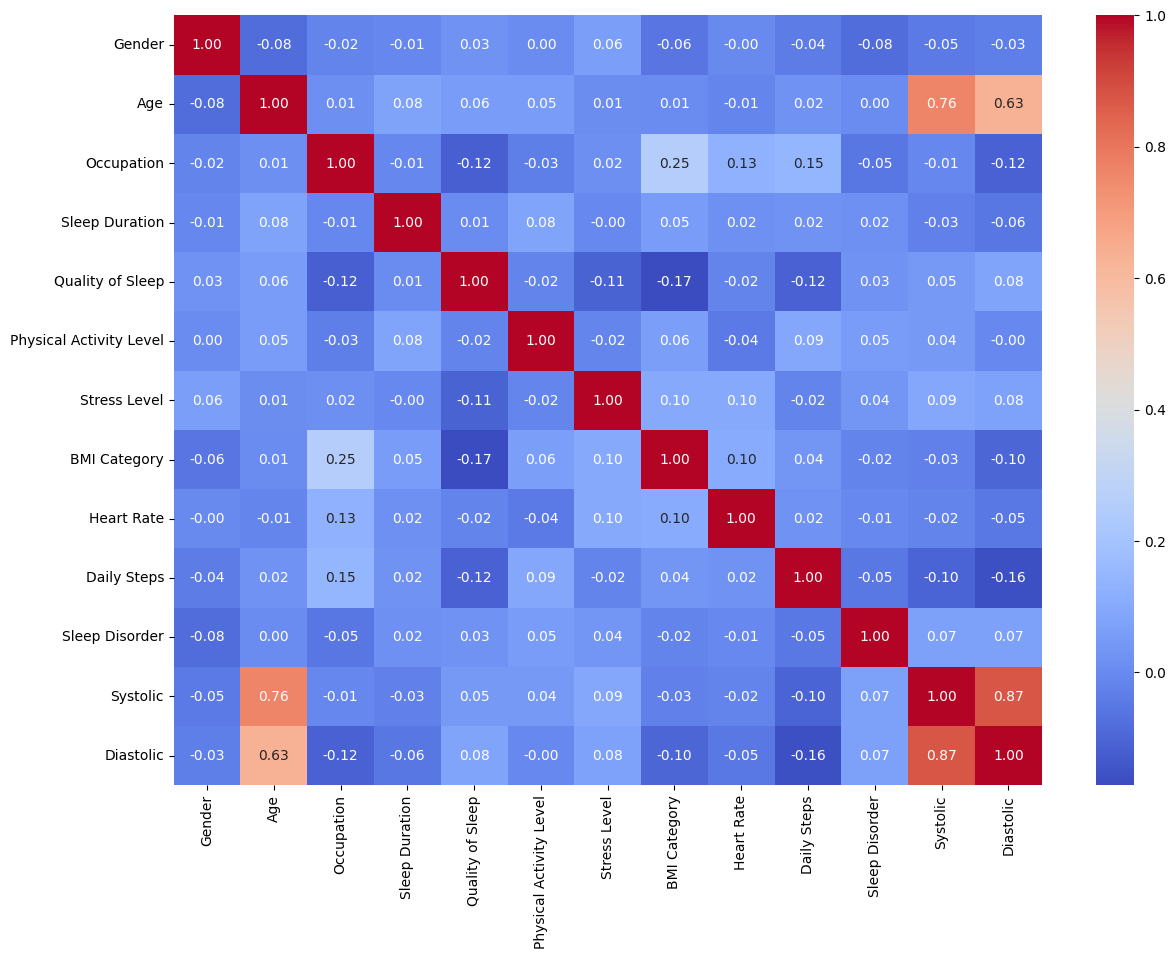

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

**Here X-axis a sleep disorder a bad a all column feature and y-axis ta hoilo target column.**

In [32]:
X = df.drop("Sleep Disorder", axis=1)
y = df["Sleep Disorder"]

**10 best feature selecton.**

In [33]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Compute MI Scores
mi_scores = mutual_info_classif(X, y)

# Convert to pandas Series for easier sorting
mi_series = pd.Series(mi_scores, index=X.columns)

# Top 10 features
top_mi = mi_series.sort_values(ascending=False).head(10)
top_mi



,0
Physical Activity Level,0.069209
Diastolic,0.054571
Heart Rate,0.052441
Sleep Duration,0.051180
Daily Steps,0.042968
Systolic,0.032553
Occupation,0.032087
Stress Level,0.021157
Quality of Sleep,0.017083
Age,0.003526


**And now list of selected feature.**

In [34]:
selected_features = [
    "Diastolic",
    "Systolic",
    "Occupation",
    "Physical Activity Level",
    "Daily Steps",
    "Sleep Duration",
    "BMI Category",
    "Gender",
    "Quality of Sleep",
    "Stress Level"
]

X = df[selected_features]
y = df["Sleep Disorder"]


**Devided target column two part one is test and other is train and X= all feature and y = target column**

In [35]:
X = df.drop("Sleep Disorder", axis=1)
y = df["Sleep Disorder"]


**Highly corelated value was drop beacuse model predict wrong.**

In [36]:
import numpy as np

corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
to_drop

['Diastolic']

**Split the train and test on targert column.**

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


**Here SMOTE apply the train data.**

In [39]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


**Here we showing how musch data test and training.**

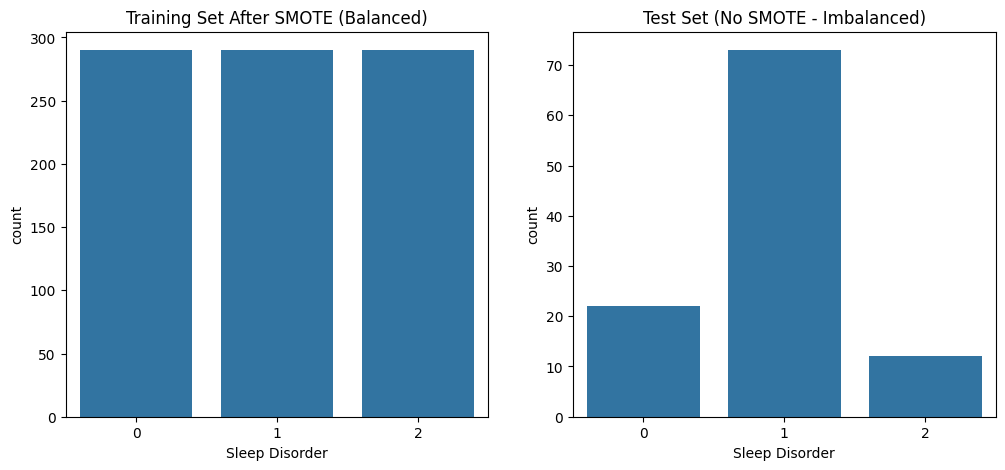

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# LEFT: Training set AFTER SMOTE
plt.subplot(1,2,1)
sns.countplot(x=y_train_res)     # Use y_train_res (SMOTE applied)
plt.title("Training Set After SMOTE (Balanced)")

# RIGHT: Test set (NO SMOTE)
plt.subplot(1,2,2)
sns.countplot(x=y_test)          # Test set remains unchanged
plt.title("Test Set (No SMOTE - Imbalanced)")

plt.show()


In [41]:
df.head(20)


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1.0,-1.024102,1.188444,-0.793656,-0.202667,-0.714183,0.198066,0.606691,0.163285,-1.131970,1,0.266468,0.732074
1,1.0,-0.946767,-1.754752,-0.747064,-0.202667,-0.112051,0.972852,-1.414769,0.014666,0.004862,1,0.149504,0.423058
3,1.0,-0.946767,0.385754,-0.886842,-1.268596,-1.115605,0.972852,-0.067129,0.757759,-1.367176,2,1.903973,1.453111
5,1.0,-0.946767,1.188444,-0.886842,-1.268596,-1.115605,0.972852,-0.067129,0.757759,-1.367176,0,1.903973,1.453111
6,1.0,-0.869433,1.723570,-0.700471,-0.202667,-0.781087,0.585459,-0.067129,0.534831,-1.269174,0,1.903973,1.453111
7,1.0,-0.869433,-1.754752,-0.001576,0.330298,0.389726,0.198066,-1.414769,-0.356880,-0.387149,1,-0.435319,0.423058
10,1.0,-0.869433,-1.754752,-0.793656,-0.202667,-1.115605,0.972852,-1.414769,-0.356880,-0.387149,1,-0.435319,0.423058
13,1.0,-0.869433,-1.754752,-0.840249,-0.202667,-1.115605,0.972852,-1.414769,-0.356880,-0.387149,1,-0.435319,0.423058
16,-1.0,-0.869433,-0.416936,-0.607285,-0.735631,-0.781087,0.585459,-0.740949,0.386213,-1.171171,2,0.968256,1.144095
17,1.0,-0.869433,-1.754752,-0.840249,-0.202667,-1.115605,0.972852,-1.414769,-0.356880,-0.387149,2,-0.435319,0.423058


In [42]:
df.head(10)

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1.0,-1.024102,1.188444,-0.793656,-0.202667,-0.714183,0.198066,0.606691,0.163285,-1.131970,1,0.266468,0.732074
1,1.0,-0.946767,-1.754752,-0.747064,-0.202667,-0.112051,0.972852,-1.414769,0.014666,0.004862,1,0.149504,0.423058
3,1.0,-0.946767,0.385754,-0.886842,-1.268596,-1.115605,0.972852,-0.067129,0.757759,-1.367176,2,1.903973,1.453111
5,1.0,-0.946767,1.188444,-0.886842,-1.268596,-1.115605,0.972852,-0.067129,0.757759,-1.367176,0,1.903973,1.453111
6,1.0,-0.869433,1.723570,-0.700471,-0.202667,-0.781087,0.585459,-0.067129,0.534831,-1.269174,0,1.903973,1.453111
7,1.0,-0.869433,-1.754752,-0.001576,0.330298,0.389726,0.198066,-1.414769,-0.356880,-0.387149,1,-0.435319,0.423058
10,1.0,-0.869433,-1.754752,-0.793656,-0.202667,-1.115605,0.972852,-1.414769,-0.356880,-0.387149,1,-0.435319,0.423058
13,1.0,-0.869433,-1.754752,-0.840249,-0.202667,-1.115605,0.972852,-1.414769,-0.356880,-0.387149,1,-0.435319,0.423058
16,-1.0,-0.869433,-0.416936,-0.607285,-0.735631,-0.781087,0.585459,-0.740949,0.386213,-1.171171,2,0.968256,1.144095
17,1.0,-0.869433,-1.754752,-0.840249,-0.202667,-1.115605,0.972852,-1.414769,-0.356880,-0.387149,2,-0.435319,0.423058


**Here checking unique value of Systolic,Diastolic.**

In [43]:
print(df["Systolic"].unique())
print(df["Diastolic"].unique())


[ 0.2664683   0.14950367  1.90397316 -0.4353195   0.9682561   0.73432683
 -0.7862134  -0.66924876  0.50039756  0.85129146 -1.02014266  1.31914999
  0.6173622  -0.55228413 -0.31835487 -0.20139023  2.13790242  1.78700853
  0.03253903  1.08522073 -0.0844256   1.20218536 -1.37103656  1.67004389
 -1.25407193  1.55307926 -1.13710729 -1.48800119  1.43611463 -1.60496583
 -1.72193046  2.48879632  0.38343293 -0.90317803  2.37183169  2.25486706]
[ 0.73207374  0.42305769  1.4531112   1.14409514  1.04108979  0.01103629
  0.93808444  0.83507909 -0.09196906  1.24710049  0.21704699  0.11404164
  0.32005234  0.62906839  1.6591219   1.96813795  1.55611655 -0.60699582
 -0.40098511 -1.63704932 -1.32803327 -1.01901722 -0.29797976  0.52606304
 -1.12202257 -0.50399047 -0.19497441 -0.91601187 -0.71000117  2.0711433
 -1.22502792 -1.53404397  1.35010585  1.76212725 -0.81300652 -1.43103862
  1.8651326 ]


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532 entries, 0 to 773
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   532 non-null    float64
 1   Age                      532 non-null    float64
 2   Occupation               532 non-null    float64
 3   Sleep Duration           532 non-null    float64
 4   Quality of Sleep         532 non-null    float64
 5   Physical Activity Level  532 non-null    float64
 6   Stress Level             532 non-null    float64
 7   BMI Category             532 non-null    float64
 8   Heart Rate               532 non-null    float64
 9   Daily Steps              532 non-null    float64
 10  Sleep Disorder           532 non-null    int64  
 11  Systolic                 532 non-null    float64
 12  Diastolic                532 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 58.2 KB


**Split the train and testing data.**

In [45]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

**Split the train+validation.**

**Validation set of train data.**

In [46]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,    # 0.25 of 0.8 = 0.20 val
    stratify=y_train_full,
    random_state=42
)


In [47]:
df.head()


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1.0,-1.024102,1.188444,-0.793656,-0.202667,-0.714183,0.198066,0.606691,0.163285,-1.131970,1,0.266468,0.732074
1,1.0,-0.946767,-1.754752,-0.747064,-0.202667,-0.112051,0.972852,-1.414769,0.014666,0.004862,1,0.149504,0.423058
3,1.0,-0.946767,0.385754,-0.886842,-1.268596,-1.115605,0.972852,-0.067129,0.757759,-1.367176,2,1.903973,1.453111
5,1.0,-0.946767,1.188444,-0.886842,-1.268596,-1.115605,0.972852,-0.067129,0.757759,-1.367176,0,1.903973,1.453111
6,1.0,-0.869433,1.723570,-0.700471,-0.202667,-0.781087,0.585459,-0.067129,0.534831,-1.269174,0,1.903973,1.453111


**All model train accuracy,f1 score, result with cross validation for tarin data**


===== Logistic Regression =====
Logistic Regression 5-fold CV Accuracy: 0.4931  (+/- 0.0324)

Confusion Matrix:
 [[114  88  88]
 [ 70 155  65]
 [ 47  60 183]] 


===== Decision Tree =====
Decision Tree 5-fold CV Accuracy: 0.7011  (+/- 0.0571)

Confusion Matrix:
 [[290   0   0]
 [  7 283   0]
 [  5   4 281]] 


===== SVM =====
SVM 5-fold CV Accuracy: 0.7609  (+/- 0.0514)

Confusion Matrix:
 [[240  34  16]
 [ 28 246  16]
 [ 23   8 259]] 


===== Random Forest =====
Random Forest 5-fold CV Accuracy: 0.8103  (+/- 0.0772)

Confusion Matrix:
 [[283   5   2]
 [  2 285   3]
 [  2   2 286]] 


===== Extra Trees =====
Extra Trees 5-fold CV Accuracy: 0.8586  (+/- 0.0763)

Confusion Matrix:
 [[290   0   0]
 [  7 283   0]
 [  5   4 281]] 


===== Gradient Boosting =====
Gradient Boosting 5-fold CV Accuracy: 0.7494  (+/- 0.0894)


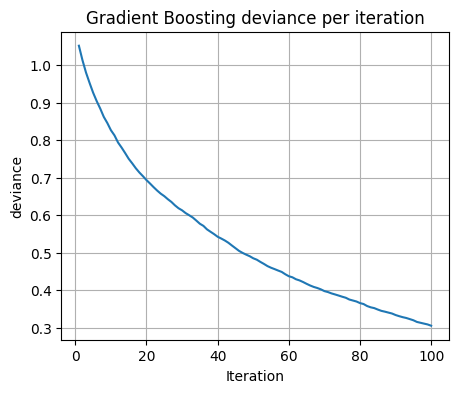


Confusion Matrix:
 [[272   8  10]
 [ 11 273   6]
 [  5   2 283]] 


===== AdaBoost =====
AdaBoost 5-fold CV Accuracy: 0.5690  (+/- 0.0592)


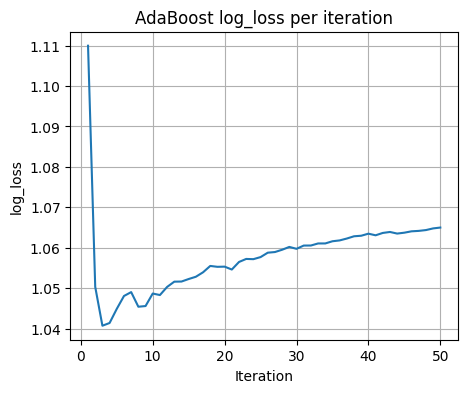


Confusion Matrix:
 [[184  66  40]
 [ 74 179  37]
 [ 53  29 208]] 


===== Bernoulli Naive Bayes =====
Bernoulli Naive Bayes 5-fold CV Accuracy: 0.4770  (+/- 0.0286)

Confusion Matrix:
 [[145  80  65]
 [ 92 124  74]
 [ 49  81 160]] 


Final Metrics Table:
                   Model  Train Accuracy  Train Precision  Train Recall  \
0    Logistic Regression        0.519540         0.516567      0.519540   
1          Decision Tree        0.981609         0.982109      0.981609   
2                    SVM        0.856322         0.856314      0.856322   
3          Random Forest        0.981609         0.981636      0.981609   
4            Extra Trees        0.981609         0.982109      0.981609   
5      Gradient Boosting        0.951724         0.951866      0.951724   
6               AdaBoost        0.656322         0.658250      0.656322   
7  Bernoulli Naive Bayes        0.493103         0.492399      0.493103   

   Train F1  CV Mean Accuracy  CV Std Accuracy  
0  0.515017        

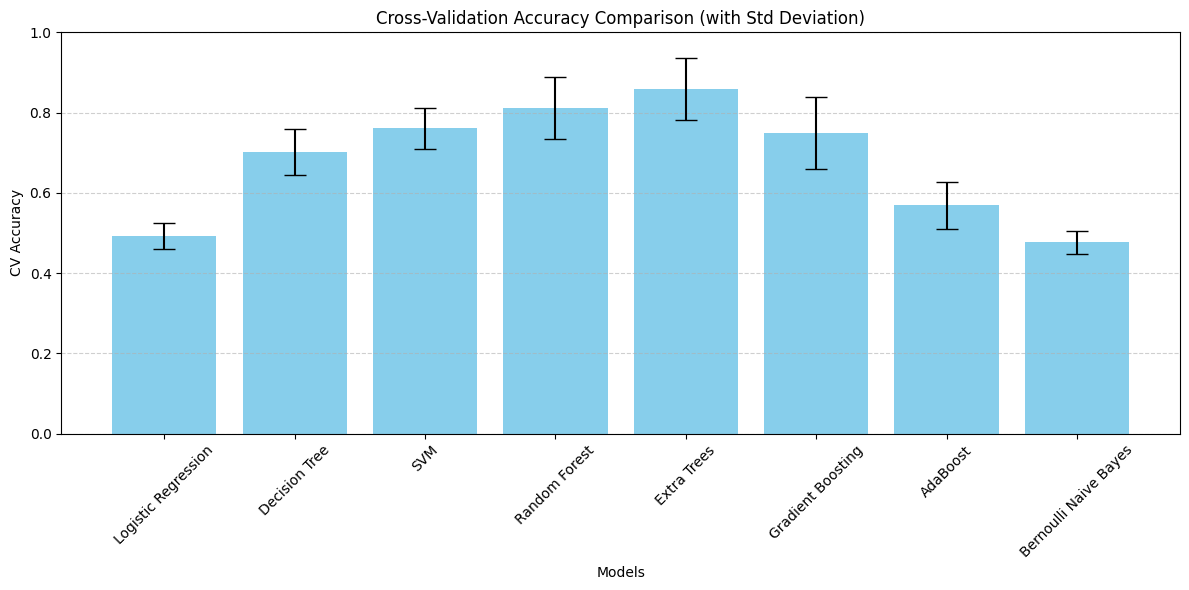

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    log_loss
)
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_loss_curve(loss_values, model_name, metric_name="loss"):
    plt.figure(figsize=(5, 4))
    plt.plot(range(1, len(loss_values) + 1), loss_values)
    plt.title(f"{model_name} {metric_name} per iteration")
    plt.xlabel("Iteration")
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.show()


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bernoulli Naive Bayes": BernoulliNB()
}

rows = []


# ==========================
# MAIN MODEL LOOP
# ==========================
for name, clf in models.items():

    print("\n==============================")
    print(f"===== {name} =====")

    # 1️⃣ CROSS VALIDATION
    cv_scores = cross_val_score(
        clf,
        X_train_res,
        y_train_res,
        cv=5,
        scoring="accuracy"
    )

    print(f"{name} 5-fold CV Accuracy: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

    # 2️⃣ TRAIN MODEL
    clf.fit(X_train_res, y_train_res)

    # 3️⃣ LOSS CURVES
    if name == "Gradient Boosting":
        if hasattr(clf, "train_score_"):
            plot_loss_curve(clf.train_score_, name, metric_name="deviance")

    elif name == "AdaBoost":
        loss_values = []
        for y_proba in clf.staged_predict_proba(X_train_res):
            loss_values.append(log_loss(y_train_res, y_proba))
        plot_loss_curve(loss_values, name, metric_name="log_loss")

    # 4️⃣ PREDICT
    y_train_pred = clf.predict(X_train_res)

    # 5️⃣ TRAIN METRICS
    train_acc  = accuracy_score(y_train_res, y_train_pred)
    train_prec = precision_score(y_train_res, y_train_pred, average="macro")
    train_rec  = recall_score(y_train_res, y_train_pred, average="macro")
    train_f1   = f1_score(y_train_res, y_train_pred, average="macro")

    # 6️⃣ CONFUSION MATRIX
    print("\nConfusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred), "\n")

    rows.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Train Precision": train_prec,
        "Train Recall": train_rec,
        "Train F1": train_f1,
        "CV Mean Accuracy": cv_scores.mean(),
        "CV Std Accuracy": cv_scores.std()
    })


# ==========================
# RESULTS DATAFRAME
# ==========================
results_df = pd.DataFrame(rows)
print("\nFinal Metrics Table:")
print(results_df)



# ======================================================
# 📊 CROSS VALIDATION ACCURACY GRAPH (ALL MODELS)
# ======================================================

x = np.arange(len(results_df["Model"]))
cv_means = results_df["CV Mean Accuracy"]
cv_stds  = results_df["CV Std Accuracy"]

plt.figure(figsize=(12, 6))
plt.bar(x, cv_means, yerr=cv_stds, capsize=8, color="skyblue")

plt.xlabel("Models")
plt.ylabel("CV Accuracy")
plt.title("Cross-Validation Accuracy Comparison (with Std Deviation)")
plt.xticks(x, results_df["Model"], rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Bar chart for evry train model.**

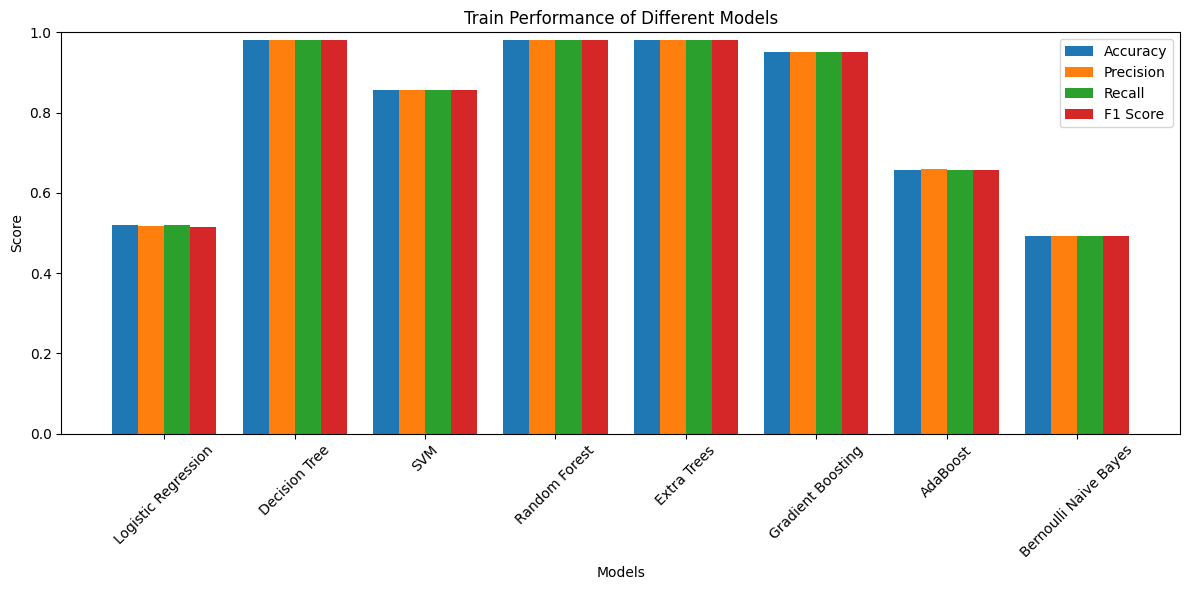

In [49]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Train Accuracy", "Train Precision", "Train Recall", "Train F1"]

x = np.arange(len(results_df["Model"]))  # model index
width = 0.2                              # bar width

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*width, results_df["Train Accuracy"],  width, label="Accuracy")
plt.bar(x - 0.5*width, results_df["Train Precision"], width, label="Precision")
plt.bar(x + 0.5*width, results_df["Train Recall"],    width, label="Recall")
plt.bar(x + 1.5*width, results_df["Train F1"],        width, label="F1 Score")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Train Performance of Different Models")
plt.xticks(x, results_df["Model"], rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


In [50]:
!pip install xgboost
!pip install catboost
!pip install lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [51]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


**catboost,LightGdm,XGBoost apply for train data.**


===== XGBoost =====
XGBoost 5-fold CV Accuracy: 0.8195 (+/- 0.0791)


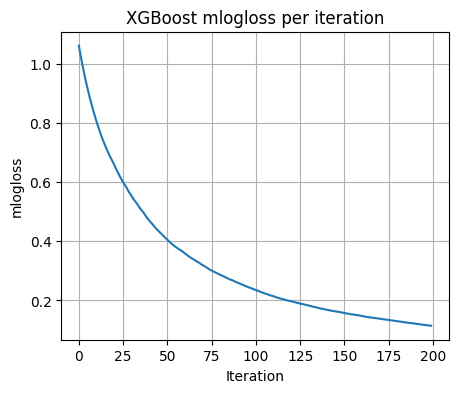


Confusion Matrix for XGBoost:
[[283   5   2]
 [  4 282   4]
 [  2   3 285]]



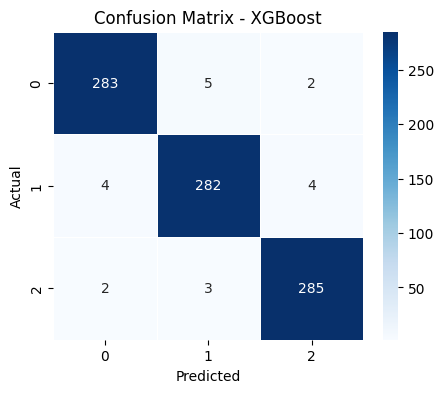


===== CatBoost =====
CatBoost 5-fold CV Accuracy: 0.7954 (+/- 0.0688)


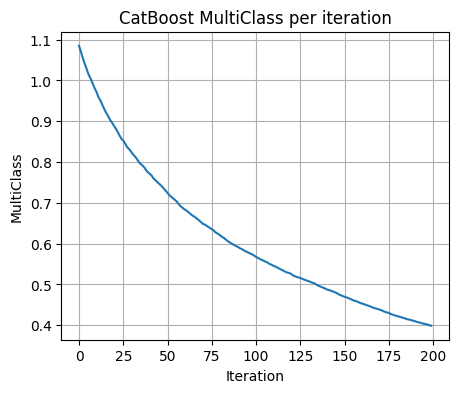


Confusion Matrix for CatBoost:
[[266   9  15]
 [  9 271  10]
 [ 10   6 274]]



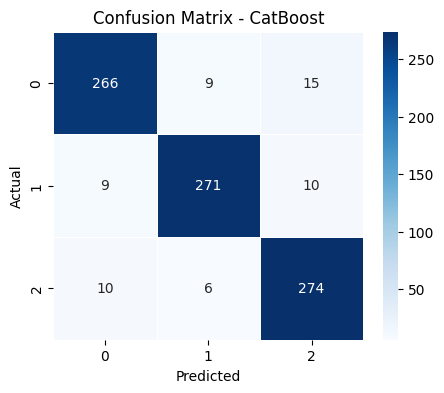


===== LightGBM =====
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2410
[LightGBM] [Info] Number of data points in the train set: 696, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

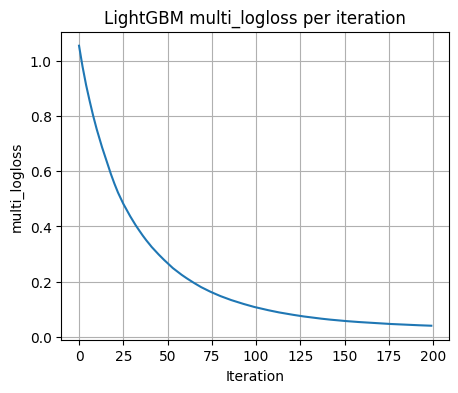


Confusion Matrix for LightGBM:
[[283   5   2]
 [  2 286   2]
 [  2   3 285]]



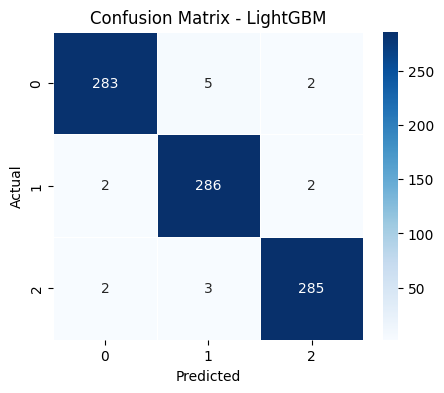


===== Boosting Models Performance (Train + Cross-Validation) =====
      Model  Train Accuracy  Train Precision  Train Recall  Train F1  \
0   XGBoost        0.977011         0.977011      0.977011  0.977009   
1  CatBoost        0.932184         0.932425      0.932184  0.932193   
2  LightGBM        0.981609         0.981670      0.981609  0.981615   

   CV Mean Accuracy  CV Std Accuracy  
0          0.819540         0.079102  
1          0.795402         0.068831  
2          0.829885         0.089817  


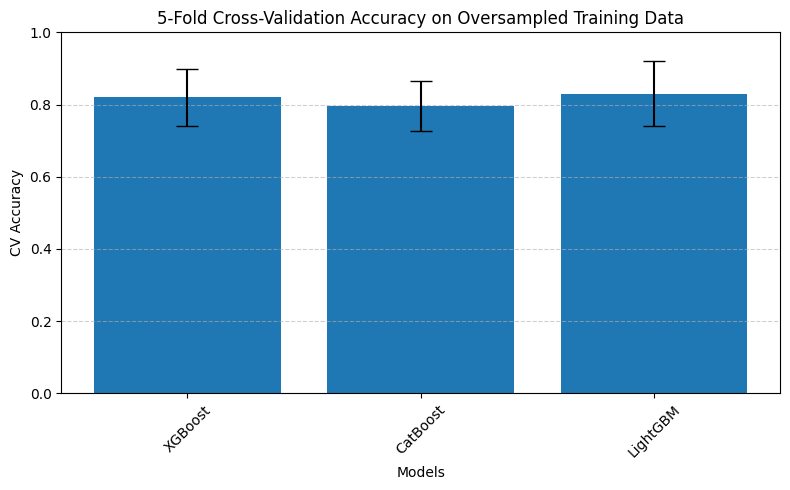

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.model_selection import cross_val_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


# -------------------------------------------------
# Helper: Confusion matrix plot
# -------------------------------------------------
def plot_conf_matrix(cm, model_name):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=.5)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# -------------------------------------------------
# Helper: Loss curve plot
# -------------------------------------------------
def plot_loss_curve(loss_values, model_name, metric_name="loss"):
    plt.figure(figsize=(5, 4))
    plt.plot(loss_values)
    plt.title(f"{model_name} {metric_name} per iteration")
    plt.xlabel("Iteration")
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.show()


# -------------------------------------------------
# Automatically detect multiclass
# -------------------------------------------------
num_classes = len(np.unique(y_train_res))
is_multiclass = num_classes > 2

# -------------------------------------------------
# Define models with correct parameters
# -------------------------------------------------

# XGBoost
xgb_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "random_state": 42,
    "n_jobs": -1,
}
if is_multiclass:
    xgb_params.update(
        objective="multi:softprob",
        eval_metric="mlogloss",
    )
else:
    xgb_params.update(
        objective="binary:logistic",
        eval_metric="logloss",
    )

# CatBoost
cat_params = {
    "iterations": 200,
    "learning_rate": 0.05,
    "verbose": 0,
    "random_state": 42,
}
if is_multiclass:
    cat_params.update(loss_function="MultiClass")
else:
    cat_params.update(loss_function="Logloss")

# LightGBM
lgbm_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "random_state": 42,
    "n_jobs": -1,
}
if is_multiclass:
    lgbm_params.update(objective="multiclass", num_class=num_classes)
else:
    lgbm_params.update(objective="binary")

boost_models = {
    "XGBoost": XGBClassifier(**xgb_params),
    "CatBoost": CatBoostClassifier(**cat_params),
    "LightGBM": LGBMClassifier(**lgbm_params),
}


# -------------------------------------------------
# Train each model + CV + loss curve + metrics
# -------------------------------------------------
boost_rows = []

for name, clf in boost_models.items():

    print(f"\n===== {name} =====")

    # 1️⃣ CROSS-VALIDATION (5-fold accuracy)
    cv_scores = cross_val_score(
        clf,
        X_train_res,      # oversampled + already standardized data
        y_train_res,
        cv=5,
        scoring="accuracy"
    )

    print(f"{name} 5-fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    # 2️⃣ Fit on full oversampled train data (for loss curve + train metrics)
    if name == "XGBoost":
        clf.fit(
            X_train_res,
            y_train_res,
            eval_set=[(X_train_res, y_train_res)],
            verbose=False
        )

        evals_result = clf.evals_result()
        dataset = list(evals_result.keys())[0]
        metric_name = list(evals_result[dataset].keys())[0]
        loss_values = evals_result[dataset][metric_name]
        plot_loss_curve(loss_values, name, metric_name)

    elif name == "CatBoost":
        clf.fit(
            X_train_res,
            y_train_res,
            eval_set=(X_train_res, y_train_res),
            verbose=False
        )

        evals_result = clf.get_evals_result()
        learn_metrics = evals_result["learn"]
        metric_name = list(learn_metrics.keys())[0]
        loss_values = learn_metrics[metric_name]
        plot_loss_curve(loss_values, name, metric_name)

    elif name == "LightGBM":
        clf.fit(
            X_train_res,
            y_train_res,
            eval_set=[(X_train_res, y_train_res)],
            eval_metric="multi_logloss" if is_multiclass else "logloss"
        )

        evals_result = clf.evals_result_
        dataset = list(evals_result.keys())[0]
        metric_name = list(evals_result[dataset].keys())[0]
        loss_values = evals_result[dataset][metric_name]
        plot_loss_curve(loss_values, name, metric_name)

    # 3️⃣ TRAIN predictions
    y_pred = clf.predict(X_train_res)

    # 4️⃣ TRAIN metrics
    acc = accuracy_score(y_train_res, y_pred)
    prec = precision_score(y_train_res, y_pred, average="macro")
    rec = recall_score(y_train_res, y_pred, average="macro")
    f1 = f1_score(y_train_res, y_pred, average="macro")

    # 5️⃣ Confusion Matrix
    cm = confusion_matrix(y_train_res, y_pred)
    print(f"\nConfusion Matrix for {name}:\n{cm}\n")
    plot_conf_matrix(cm, name)

    boost_rows.append({
        "Model": name,
        "Train Accuracy": acc,
        "Train Precision": prec,
        "Train Recall": rec,
        "Train F1": f1,
        "CV Mean Accuracy": cv_scores.mean(),
        "CV Std Accuracy": cv_scores.std()
    })

# -------------------------------------------------
# Final summary table
# -------------------------------------------------
boost_results_df = pd.DataFrame(boost_rows)
print("\n===== Boosting Models Performance (Train + Cross-Validation) =====")
print(boost_results_df)

# -------------------------------------------------
# Cross-Validation Accuracy Graph (Train/Oversampled Data)
# -------------------------------------------------
x = np.arange(len(boost_results_df["Model"]))
cv_means = boost_results_df["CV Mean Accuracy"]
cv_stds  = boost_results_df["CV Std Accuracy"]

plt.figure(figsize=(8, 5))
plt.bar(x, cv_means, yerr=cv_stds, capsize=8)

plt.xlabel("Models")
plt.ylabel("CV Accuracy")
plt.title("5-Fold Cross-Validation Accuracy on Oversampled Training Data")
plt.xticks(x, boost_results_df["Model"], rotation=45)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



**Ber plot of Boosting models performance only train data.**

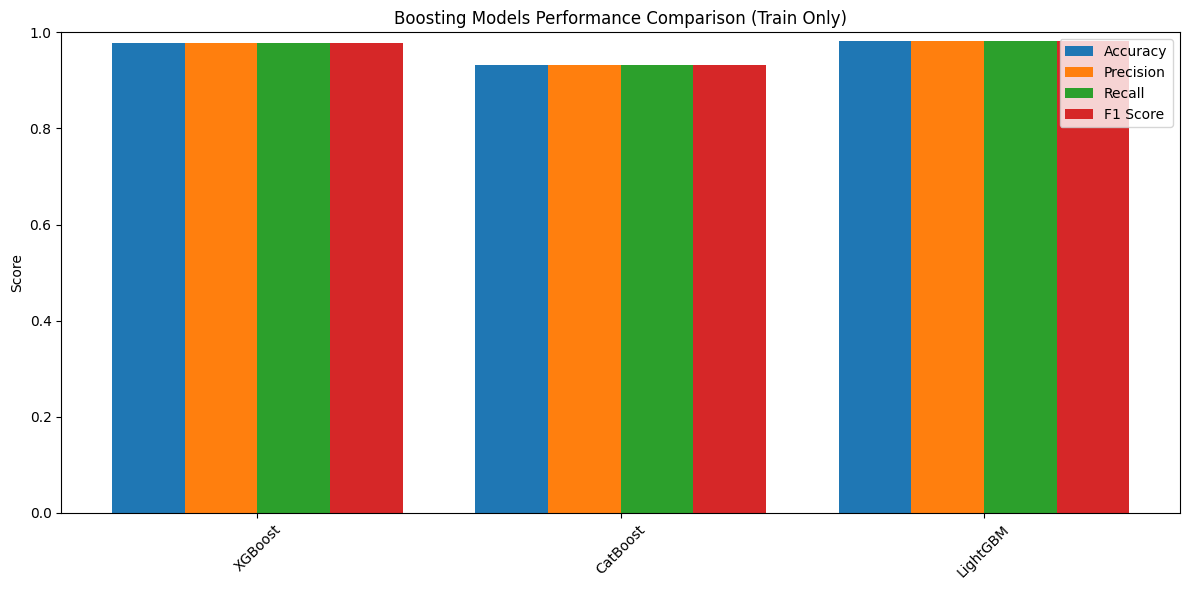

In [53]:
import numpy as np
import matplotlib.pyplot as plt

models = boost_results_df["Model"]
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*width, boost_results_df["Train Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, boost_results_df["Train Precision"], width, label="Precision")
plt.bar(x + 0.5*width, boost_results_df["Train Recall"], width, label="Recall")
plt.bar(x + 1.5*width, boost_results_df["Train F1"], width, label="F1 Score")

plt.xticks(x, models, rotation=45)
plt.ylabel("Score")
plt.title("Boosting Models Performance Comparison (Train Only)")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


**Now apply for the testing data.**

Shapes:
X_train_res_scaled: (870, 12)
y_train_res: (870,)
X_test_scaled: (107, 12)
y_test: (107,)

      Logistic Regression

Confusion Matrix (TEST DATA):
[[ 9  3 10]
 [21 38 14]
 [ 5  1  6]] 

Test Accuracy:  0.4953
Test Precision: 0.4540
Test Recall:    0.4765
Test F1-score:  0.4208

      Decision Tree

Confusion Matrix (TEST DATA):
[[ 6 14  2]
 [10 56  7]
 [ 1 10  1]] 

Test Accuracy:  0.5888
Test Precision: 0.3843
Test Recall:    0.3744
Test F1-score:  0.3769

      SVM

Confusion Matrix (TEST DATA):
[[ 9 10  3]
 [12 56  5]
 [ 1  7  4]] 

Test Accuracy:  0.6449
Test Precision: 0.5032
Test Recall:    0.5032
Test F1-score:  0.5032

      Random Forest

Confusion Matrix (TEST DATA):
[[ 4 15  3]
 [10 61  2]
 [ 0 10  2]] 

Test Accuracy:  0.6262
Test Precision: 0.4269
Test Recall:    0.3947
Test F1-score:  0.4000

      Extra Trees

Confusion Matrix (TEST DATA):
[[ 4 17  1]
 [ 7 64  2]
 [ 1 10  1]] 

Test Accuracy:  0.6449
Test Precision: 0.4289
Test Recall:    0.3806
Test F1-score:  

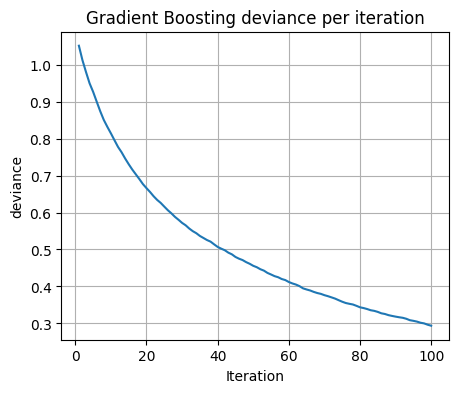


Confusion Matrix (TEST DATA):
[[ 3 15  4]
 [11 59  3]
 [ 4  4  4]] 

Test Accuracy:  0.6168
Test Precision: 0.4289
Test Recall:    0.4260
Test F1-score:  0.4264

      AdaBoost


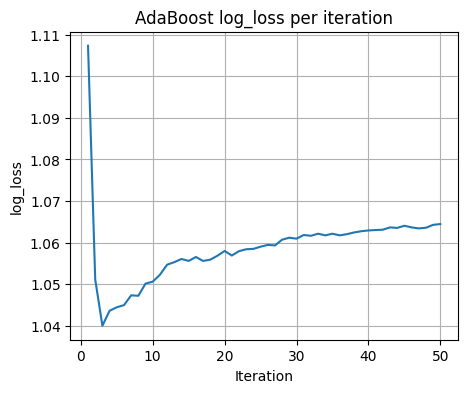


Confusion Matrix (TEST DATA):
[[ 7  9  6]
 [11 54  8]
 [ 1  7  4]] 

Test Accuracy:  0.6075
Test Precision: 0.4540
Test Recall:    0.4637
Test F1-score:  0.4545

      Bernoulli Naive Bayes

Confusion Matrix (TEST DATA):
[[10  3  9]
 [16 43 14]
 [ 2  5  5]] 

Test Accuracy:  0.5421
Test Precision: 0.4596
Test Recall:    0.4868
Test F1-score:  0.4478

==== Final MODEL SUMMARY (TEST ONLY) ====

                   Model  Test Accuracy  Test Precision  Test Recall   Test F1
0    Logistic Regression       0.495327        0.453968     0.476546  0.420791
1          Decision Tree       0.588785        0.384314     0.374395  0.376876
2                    SVM       0.644860        0.503183     0.503183  0.503183
3          Random Forest       0.626168        0.426910     0.394700  0.400015
4            Extra Trees       0.644860        0.428877     0.380621  0.380261
5      Gradient Boosting       0.616822        0.428904     0.425972  0.426428
6               AdaBoost       0.607477        0.4

In [54]:
# ======================================
# 1. IMPORTS
# ======================================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    log_loss,
)

# ======================================
# 2. DATA SPLIT + SMOTE + SCALER
# ======================================

target = "Sleep Disorder"   # তোমার target column

X = df.drop(columns=[target])
y = df[target]

# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---- SMOTE (only on TRAIN) ----
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# ---- StandardScaler (fit on train_res, transform train_res + test) ----
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Shapes:")
print("X_train_res_scaled:", X_train_res_scaled.shape)
print("y_train_res:", y_train_res.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_test:", y_test.shape)

# ======================================
# 3. Loss Curve plot function
# ======================================
def plot_loss_curve(loss_values, model_name, metric_name="loss"):
    plt.figure(figsize=(5, 4))
    plt.plot(range(1, len(loss_values) + 1), loss_values)
    plt.title(f"{model_name} {metric_name} per iteration")
    plt.xlabel("Iteration")
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.show()

# ======================================
# 4. Models ডিফাইন
# ======================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),  # শুধুই ক্লাসিফিকেশন; proba দরকার নেই
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bernoulli Naive Bayes": BernoulliNB(),
}

# ======================================
# 5. Main Loop: Train + Test + Confusion Matrix + (Loss Curve for GB & Ada)
# ======================================
rows = []

for name, clf in models.items():
    print("\n==============================")
    print(f"      {name}")
    print("==============================")

    # ----- 1) Train on full TRAIN (SMOTE + Scaled) -----
    clf.fit(X_train_res_scaled, y_train_res)

    # ----- 2) LOSS CURVE: শুধু Gradient Boosting & AdaBoost -----
    if name == "Gradient Boosting":
        if hasattr(clf, "train_score_"):
            loss_values = clf.train_score_  # deviance (approx loss)
            plot_loss_curve(loss_values, name, metric_name="deviance")

    elif name == "AdaBoost":
        if hasattr(clf, "staged_predict_proba"):
            loss_values = []
            for proba in clf.staged_predict_proba(X_train_res_scaled):
                loss_values.append(log_loss(y_train_res, proba))
            plot_loss_curve(loss_values, name, metric_name="log_loss")

    # ----- 3) TEST prediction -----
    y_test_pred = clf.predict(X_test_scaled)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average="macro")
    test_rec = recall_score(y_test, y_test_pred, average="macro")
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # ----- 4) Confusion Matrix -----
    cm = confusion_matrix(y_test, y_test_pred)
    print("\nConfusion Matrix (TEST DATA):")
    print(cm, "\n")

    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Test Precision: {test_prec:.4f}")
    print(f"Test Recall:    {test_rec:.4f}")
    print(f"Test F1-score:  {test_f1:.4f}")

    # summary table এর জন্য সেভ করছি
    rows.append(
        {
            "Model": name,
            "Test Accuracy": test_acc,
            "Test Precision": test_prec,
            "Test Recall": test_rec,
            "Test F1": test_f1,
        }
    )

# ======================================
# 6. Final summary table
# ======================================
results_test_df = pd.DataFrame(rows)
print("\n==== Final MODEL SUMMARY (TEST ONLY) ====\n")
print(results_test_df)


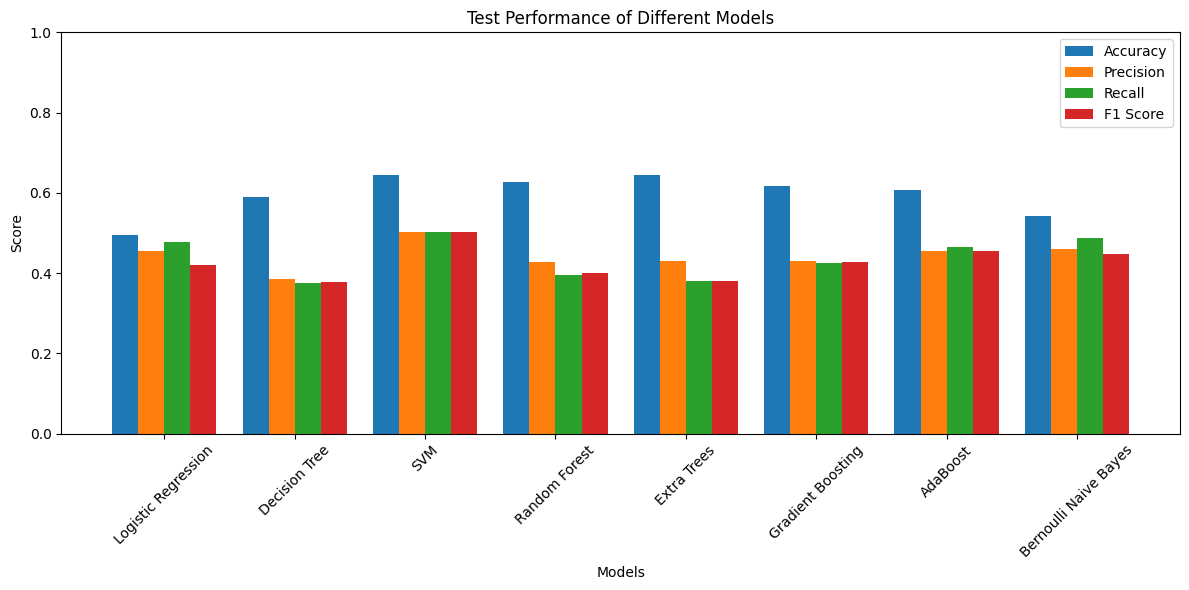

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# x-axis এ model index
x = np.arange(len(results_test_df["Model"]))
width = 0.2  # bar width

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5*width, results_test_df["Test Accuracy"],  width, label="Accuracy")
plt.bar(x - 0.5*width, results_test_df["Test Precision"], width, label="Precision")
plt.bar(x + 0.5*width, results_test_df["Test Recall"],    width, label="Recall")
plt.bar(x + 1.5*width, results_test_df["Test F1"],        width, label="F1 Score")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Test Performance of Different Models")
plt.xticks(x, results_test_df["Model"], rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


**Catboost,XGBboost,lightGdm apply for test data.**


===== Training XGBoost =====


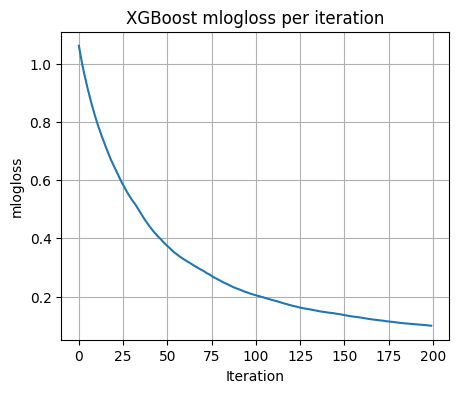


Confusion Matrix for XGBoost (TEST DATA):
[[ 7 14  1]
 [ 9 59  5]
 [ 1  7  4]]



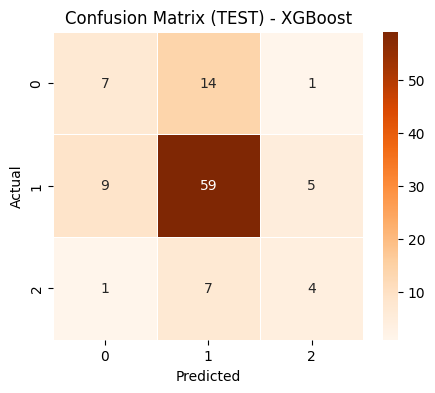


===== Training CatBoost =====


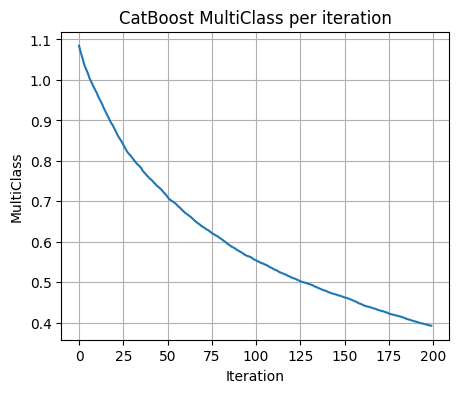


Confusion Matrix for CatBoost (TEST DATA):
[[ 6 13  3]
 [11 56  6]
 [ 0  7  5]]



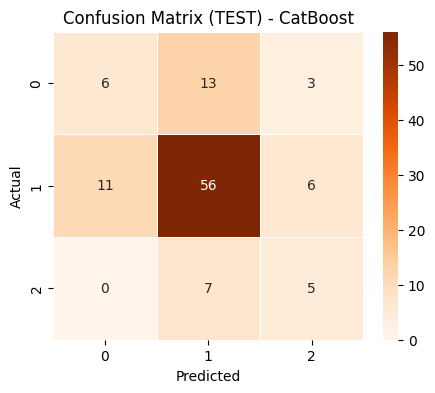


===== Training LightGBM =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2639
[LightGBM] [Info] Number of data points in the train set: 870, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


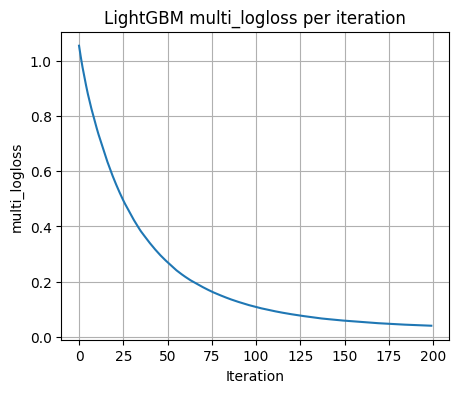

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Confusion Matrix for LightGBM (TEST DATA):
[[ 7 12  3]
 [11 60  2]
 [ 0 10  2]]



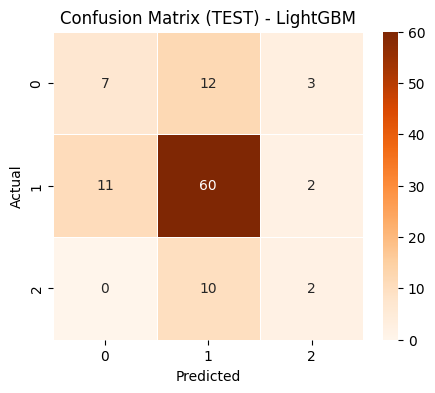


Boosting Models Performance (TEST DATA):
      Model  Test Accuracy  Test Precision  Test Recall   Test F1
0   XGBoost       0.654206        0.516422     0.486578  0.497951
1  CatBoost       0.626168        0.482309     0.485506  0.481329
2  LightGBM       0.644860        0.468770     0.435589  0.444907


In [56]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# ================== Confusion Matrix Plot ==================
def plot_conf_matrix(cm, model_name):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", linewidths=.5)
    plt.title(f"Confusion Matrix (TEST) - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ================== Loss Curve Plot ==================
def plot_loss_curve(loss_values, model_name, metric_name="loss"):
    plt.figure(figsize=(5,4))
    plt.plot(loss_values)
    plt.title(f"{model_name} {metric_name} per iteration")
    plt.xlabel("Iteration")
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.show()

# ================== Multiclass or Binary ==================
num_classes = len(np.unique(y_train_res))
is_multiclass = num_classes > 2

# ================== Models ==================
boost_models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        objective="multi:softprob" if is_multiclass else "binary:logistic",
        eval_metric="mlogloss" if is_multiclass else "logloss",
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        verbose=0,
        random_state=42,
        loss_function="MultiClass" if is_multiclass else "Logloss",
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        objective="multiclass" if is_multiclass else "binary",
        **({"num_class": num_classes} if is_multiclass else {})
    )
}

boost_rows_test = []

for name, clf in boost_models.items():
    print(f"\n===== Training {name} =====")

    # ---------- TRAIN + LOSS CURVE ----------
    if name == "XGBoost":
        clf.fit(
            X_train_res_scaled,
            y_train_res,
            eval_set=[(X_train_res_scaled, y_train_res)],
            verbose=False
        )
        evals_result = clf.evals_result()
        dataset_name = list(evals_result.keys())[0]          # e.g. 'validation_0'
        metric_name = list(evals_result[dataset_name].keys())[0]  # 'mlogloss'/'logloss'
        loss_values = evals_result[dataset_name][metric_name]
        plot_loss_curve(loss_values, name, metric_name)

    elif name == "CatBoost":
        clf.fit(
            X_train_res_scaled,
            y_train_res,
            eval_set=(X_train_res_scaled, y_train_res),
            verbose=False
        )
        evals_result = clf.get_evals_result()
        learn_metrics = evals_result["learn"]
        metric_name = list(learn_metrics.keys())[0]          # 'MultiClass' or 'Logloss'
        loss_values = learn_metrics[metric_name]
        plot_loss_curve(loss_values, name, metric_name)

    elif name == "LightGBM":
        clf.fit(
            X_train_res_scaled,
            y_train_res,
            eval_set=[(X_train_res_scaled, y_train_res)],
            eval_metric="multi_logloss" if is_multiclass else "logloss",
        )
        evals_result = clf.evals_result_
        dataset_name = list(evals_result.keys())[0]          # e.g. 'valid_0'
        metric_name = list(evals_result[dataset_name].keys())[0]  # 'multi_logloss'/'logloss'
        loss_values = evals_result[dataset_name][metric_name]
        plot_loss_curve(loss_values, name, metric_name)

    # ---------- TEST Predictions ----------
    y_test_pred = clf.predict(X_test_scaled)

    test_acc  = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average="macro")
    test_rec  = recall_score(y_test, y_test_pred, average="macro")
    test_f1   = f1_score(y_test, y_test_pred, average="macro")

    # ---------- TEST Confusion Matrix ----------
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"\nConfusion Matrix for {name} (TEST DATA):\n{cm}\n")
    plot_conf_matrix(cm, name)

    boost_rows_test.append({
        "Model": name,
        "Test Accuracy": test_acc,
        "Test Precision": test_prec,
        "Test Recall": test_rec,
        "Test F1": test_f1,
    })

boost_test_results_df = pd.DataFrame(boost_rows_test)
print("\nBoosting Models Performance (TEST DATA):")
print(boost_test_results_df)


**Showing ber plot for XGBoost,CATBoost,LightGBM**

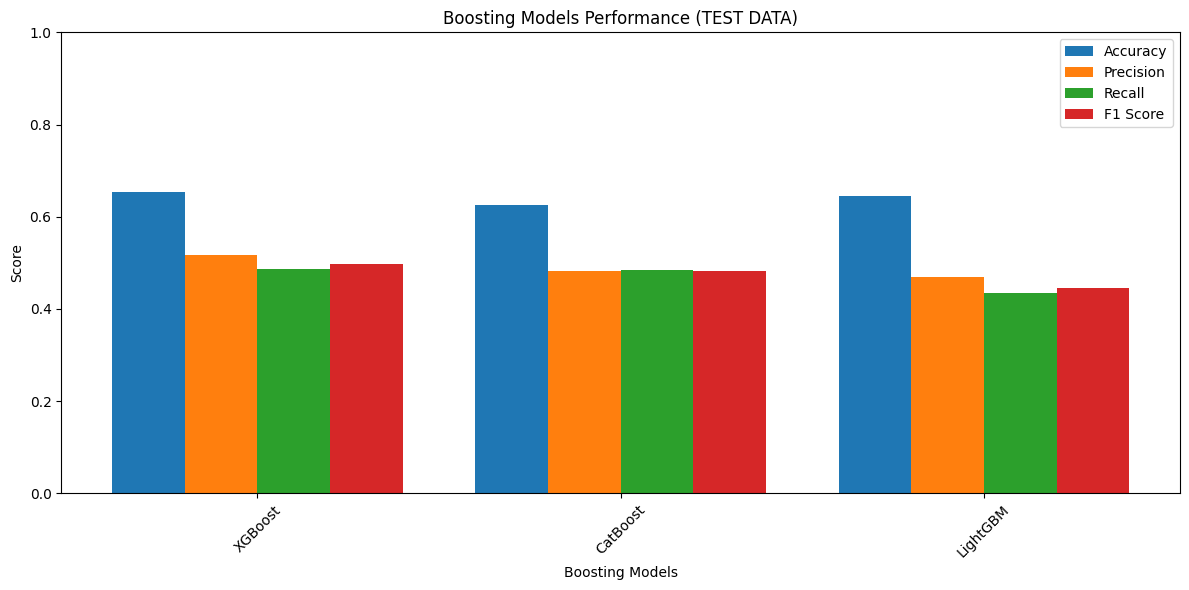

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# x-axis: model index
x = np.arange(len(boost_test_results_df["Model"]))
width = 0.2  # width of bars

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5*width, boost_test_results_df["Test Accuracy"],  width, label="Accuracy")
plt.bar(x - 0.5*width, boost_test_results_df["Test Precision"], width, label="Precision")
plt.bar(x + 0.5*width, boost_test_results_df["Test Recall"],    width, label="Recall")
plt.bar(x + 1.5*width, boost_test_results_df["Test F1"],        width, label="F1 Score")

plt.xlabel("Boosting Models")
plt.ylabel("Score")
plt.title("Boosting Models Performance (TEST DATA)")
plt.xticks(x, boost_test_results_df["Model"], rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


**Loss graph train vs testing.**

Shapes:
X_train_res_scaled: (870, 12)
y_train_res: (870,)
X_test_scaled: (107, 12)
y_test: (107,)

      Logistic Regression
Train Accuracy:  0.5023
Train Precision: 0.4982
Train Recall:    0.5023
Train F1-score:  0.4990

Confusion Matrix (TEST DATA):
[[ 9  3 10]
 [21 38 14]
 [ 5  1  6]] 

Test Accuracy:  0.4953
Test Precision: 0.4540
Test Recall:    0.4765
Test F1-score:  0.4208

      Decision Tree
Train Accuracy:  0.9816
Train Precision: 0.9821
Train Recall:    0.9816
Train F1-score:  0.9816

Confusion Matrix (TEST DATA):
[[ 6 14  2]
 [13 51  9]
 [ 1  9  2]] 

Test Accuracy:  0.5514
Test Precision: 0.3810
Test Recall:    0.3793
Test F1-score:  0.3799

      SVM
Train Accuracy:  0.8609
Train Precision: 0.8611
Train Recall:    0.8609
Train F1-score:  0.8604

Confusion Matrix (TEST DATA):
[[ 9 10  3]
 [12 56  5]
 [ 1  7  4]] 

Test Accuracy:  0.6449
Test Precision: 0.5032
Test Recall:    0.5032
Test F1-score:  0.5032

      Random Forest
Train Accuracy:  0.9816
Train Precision: 0.9818


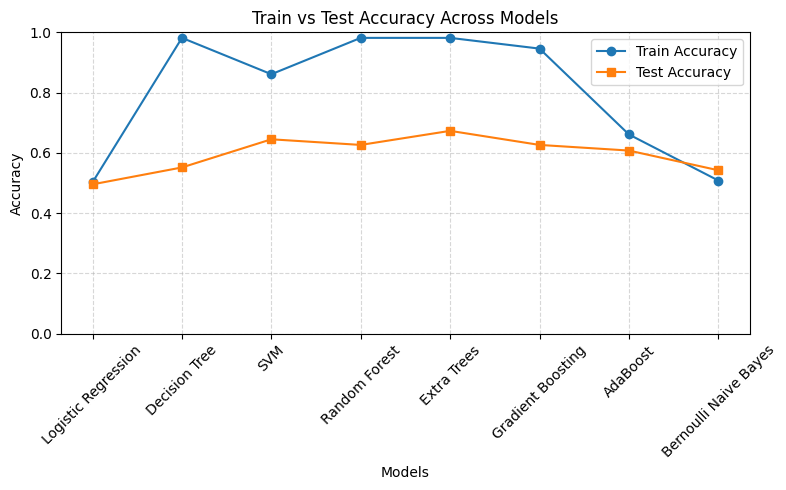

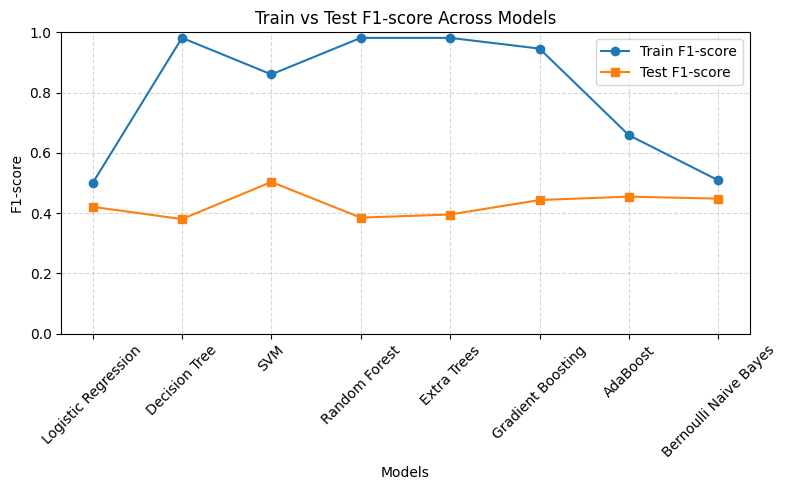

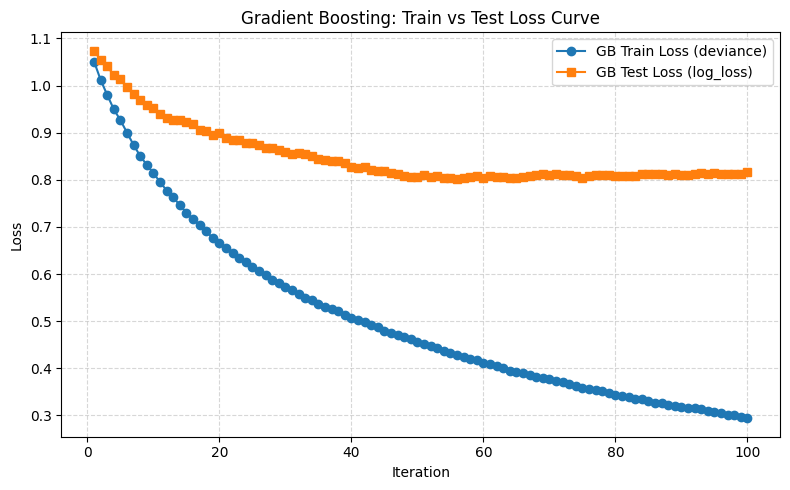

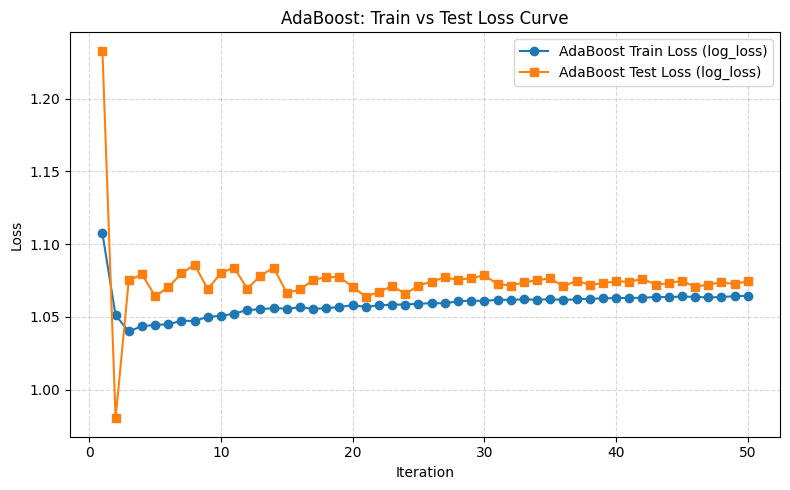

In [58]:
# ======================================
# 1. IMPORTS
# ======================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    log_loss,
)

# ======================================
# 2. DATA SPLIT + SMOTE + SCALER
# ======================================

target = "Sleep Disorder"   # তোমার target column

X = df.drop(columns=[target])
y = df[target]

# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---- SMOTE (only on TRAIN) ----
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# ---- StandardScaler (fit on train_res, transform train_res + test) ----
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Shapes:")
print("X_train_res_scaled:", X_train_res_scaled.shape)
print("y_train_res:", y_train_res.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_test:", y_test.shape)

# ======================================
# 3. Models ডিফাইন
# ======================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),  # শুধুই ক্লাসিফিকেশন; proba দরকার নেই
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bernoulli Naive Bayes": BernoulliNB(),
}

# ======================================
# 4. Main Loop: Train + (Train & Test Metrics) + Confusion Matrix
#    + GradientBoosting & AdaBoost এর জন্য loss collect (train + test)
# ======================================
rows = []

# Loss curves store করার জন্য
gb_train_loss = None
gb_test_loss = None
ada_train_loss = None
ada_test_loss = None

for name, clf in models.items():
    print("\n==============================")
    print(f"      {name}")
    print("==============================")

    # ----- 1) Train on full TRAIN (SMOTE + Scaled) -----
    clf.fit(X_train_res_scaled, y_train_res)

    # ----- 2) LOSS collect: শুধু Gradient Boosting & AdaBoost -----
    if name == "Gradient Boosting":
        # Train loss (deviance)
        if hasattr(clf, "train_score_"):
            gb_train_loss = clf.train_score_

        # Test loss per iteration using staged_predict_proba
        gb_test_loss = []
        if hasattr(clf, "staged_predict_proba"):
            for proba_test in clf.staged_predict_proba(X_test_scaled):
                gb_test_loss.append(log_loss(y_test, proba_test))

    elif name == "AdaBoost":
        if hasattr(clf, "staged_predict_proba"):
            ada_train_loss = []
            ada_test_loss = []
            # Train এবং Test — দুইটাই একসাথে iterate করব
            for proba_train, proba_test in zip(
                clf.staged_predict_proba(X_train_res_scaled),
                clf.staged_predict_proba(X_test_scaled)
            ):
                ada_train_loss.append(log_loss(y_train_res, proba_train))
                ada_test_loss.append(log_loss(y_test, proba_test))

    # ----- 3) TRAIN prediction -----
    y_train_pred = clf.predict(X_train_res_scaled)

    train_acc  = accuracy_score(y_train_res, y_train_pred)
    train_prec = precision_score(y_train_res, y_train_pred, average="macro")
    train_rec  = recall_score(y_train_res, y_train_pred, average="macro")
    train_f1   = f1_score(y_train_res, y_train_pred, average="macro")

    print(f"Train Accuracy:  {train_acc:.4f}")
    print(f"Train Precision: {train_prec:.4f}")
    print(f"Train Recall:    {train_rec:.4f}")
    print(f"Train F1-score:  {train_f1:.4f}")

    # ----- 4) TEST prediction -----
    y_test_pred = clf.predict(X_test_scaled)

    test_acc  = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average="macro")
    test_rec  = recall_score(y_test, y_test_pred, average="macro")
    test_f1   = f1_score(y_test, y_test_pred, average="macro")

    # ----- 5) Confusion Matrix (TEST) -----
    cm = confusion_matrix(y_test, y_test_pred)
    print("\nConfusion Matrix (TEST DATA):")
    print(cm, "\n")

    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Test Precision: {test_prec:.4f}")
    print(f"Test Recall:    {test_rec:.4f}")
    print(f"Test F1-score:  {test_f1:.4f}")

    rows.append(
        {
            "Model": name,
            "Train Accuracy": train_acc,
            "Train Precision": train_prec,
            "Train Recall": train_rec,
            "Train F1": train_f1,
            "Test Accuracy": test_acc,
            "Test Precision": test_prec,
            "Test Recall": test_rec,
            "Test F1": test_f1,
        }
    )

# ======================================
# 5. Final summary table
# ======================================
results_test_df = pd.DataFrame(rows)
print("\n==== Final MODEL SUMMARY (TRAIN & TEST) ====\n")
print(results_test_df)

# ======================================
# 6. Train vs Test Accuracy Curve (সব মডেল)
# ======================================
models_names = results_test_df["Model"].values
train_acc = results_test_df["Train Accuracy"].values
test_acc  = results_test_df["Test Accuracy"].values

x = np.arange(len(models_names))

plt.figure(figsize=(8, 5))
plt.plot(x, train_acc, marker="o", label="Train Accuracy")
plt.plot(x, test_acc, marker="s", label="Test Accuracy")

plt.xticks(x, models_names, rotation=45)
plt.ylim(0, 1)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy Across Models")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================
# 7. Train vs Test F1-score Curve (সব মডেল)
# ======================================
train_f1 = results_test_df["Train F1"].values
test_f1  = results_test_df["Test F1"].values

plt.figure(figsize=(8, 5))
plt.plot(x, train_f1, marker="o", label="Train F1-score")
plt.plot(x, test_f1, marker="s", label="Test F1-score")

plt.xticks(x, models_names, rotation=45)
plt.ylim(0, 1)
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.title("Train vs Test F1-score Across Models")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================
# 8. Gradient Boosting: Train vs Test Loss Curve
# ======================================
if gb_train_loss is not None and gb_test_loss is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(gb_train_loss) + 1), gb_train_loss,
             marker="o", label="GB Train Loss (deviance)")
    plt.plot(range(1, len(gb_test_loss) + 1), gb_test_loss,
             marker="s", label="GB Test Loss (log_loss)")

    plt.title("Gradient Boosting: Train vs Test Loss Curve")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ======================================
# 9. AdaBoost: Train vs Test Loss Curve
# ======================================
if ada_train_loss is not None and ada_test_loss is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(ada_train_loss) + 1), ada_train_loss,
             marker="o", label="AdaBoost Train Loss (log_loss)")
    plt.plot(range(1, len(ada_test_loss) + 1), ada_test_loss,
             marker="s", label="AdaBoost Test Loss (log_loss)")

    plt.title("AdaBoost: Train vs Test Loss Curve")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


**Catboost,XGBoost,LightGBM er jonno train vs test curve with loss curve.**

Shapes:
X_train_res: (870, 12)
y_train_res: (870,)
X_test: (107, 12)
y_test: (107,)
Multiclass: True | #classes: 3

           XGBoost


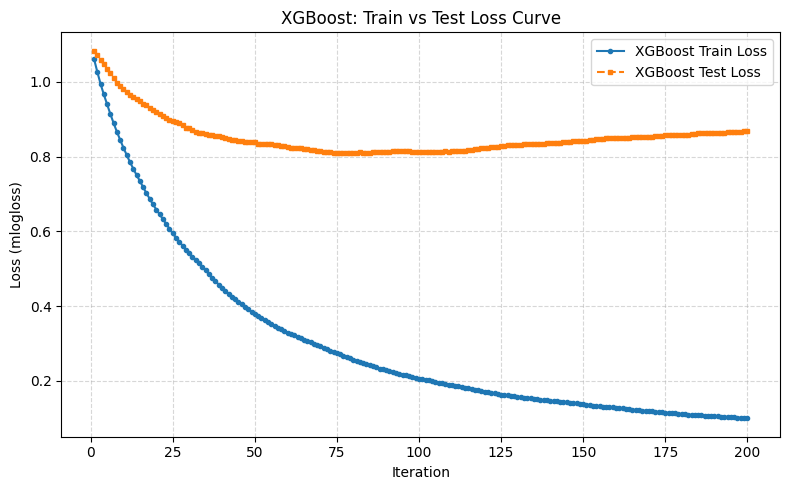

Train Accuracy:  0.9782
Train Precision: 0.9783
Train Recall:    0.9782
Train F1-score:  0.9782
Test Accuracy:  0.6542
Test Precision: 0.5164
Test Recall:    0.4866
Test F1-score:  0.4980

Confusion Matrix (TEST):
[[ 7 14  1]
 [ 9 59  5]
 [ 1  7  4]] 


           CatBoost


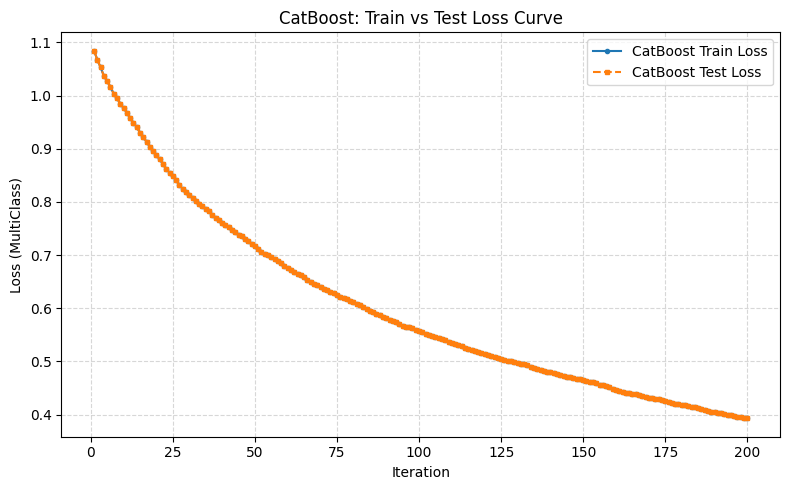

Train Accuracy:  0.9356
Train Precision: 0.9359
Train Recall:    0.9356
Train F1-score:  0.9356
Test Accuracy:  0.6355
Test Precision: 0.4976
Test Recall:    0.5007
Test F1-score:  0.4971

Confusion Matrix (TEST):
[[ 7 12  3]
 [11 56  6]
 [ 0  7  5]] 


           LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2637
[LightGBM] [Info] Number of data points in the train set: 870, number of used features: 12
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

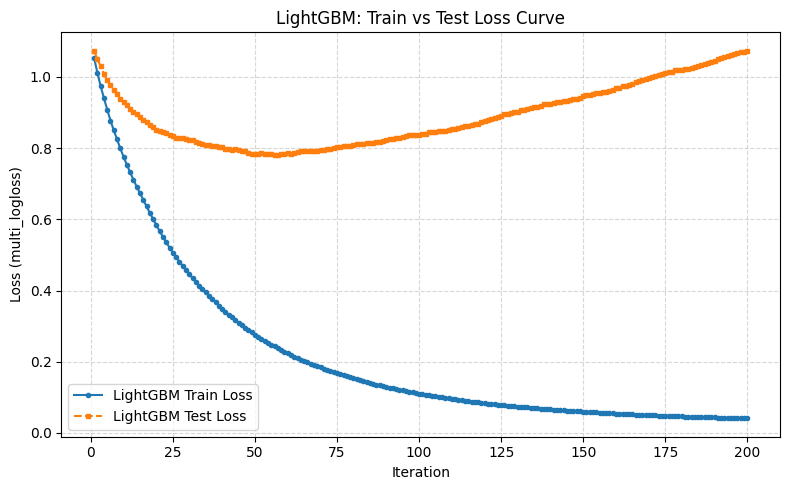

Train Accuracy:  0.9816
Train Precision: 0.9818
Train Recall:    0.9816
Train F1-score:  0.9816
Test Accuracy:  0.6542
Test Precision: 0.5098
Test Recall:    0.4402
Test F1-score:  0.4555

Confusion Matrix (TEST):
[[ 7 14  1]
 [10 61  2]
 [ 0 10  2]] 


===== Boosting Models: Train & Test Performance =====
      Model  Train Accuracy  Train Precision  Train Recall  Train F1  \
0   XGBoost        0.978161         0.978276      0.978161  0.978166   
1  CatBoost        0.935632         0.935902      0.935632  0.935648   
2  LightGBM        0.981609         0.981782      0.981609  0.981611   

   Test Accuracy  Test Precision  Test Recall   Test F1  
0       0.654206        0.516422     0.486578  0.497951  
1       0.635514        0.497566     0.500657  0.497124  
2       0.654206        0.509804     0.440155  0.455473  


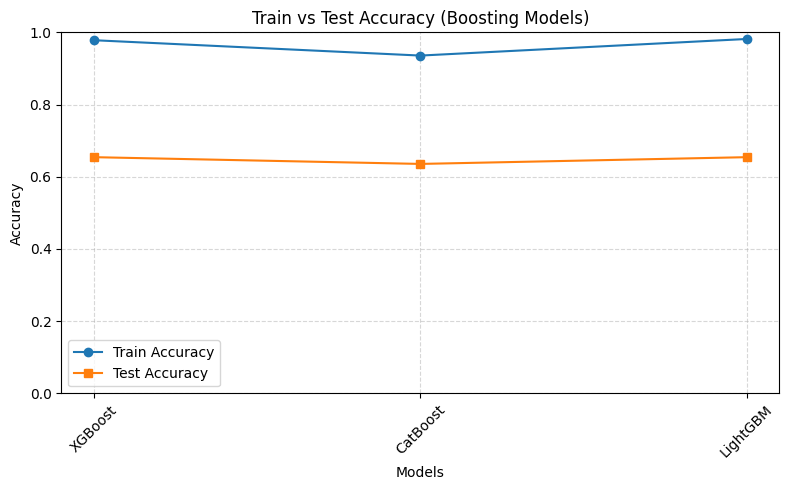

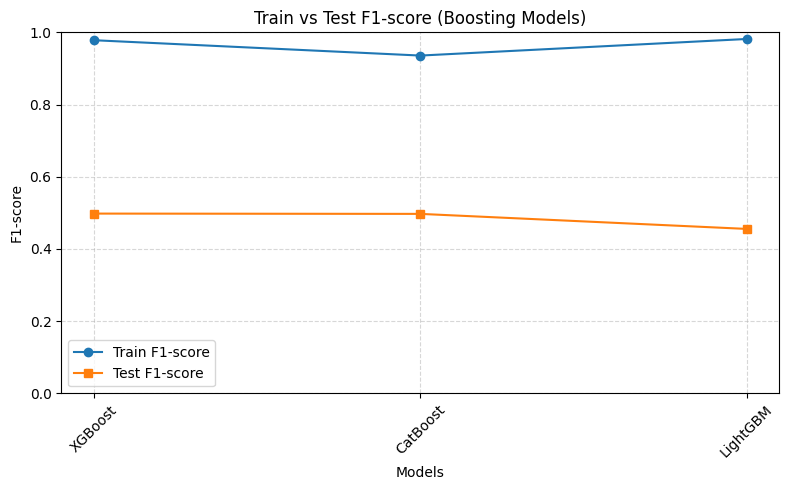

In [59]:
# ======================================
# 1. IMPORTS
# ======================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    log_loss,
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


# ======================================
# 2. DATA SPLIT + SMOTE
# ======================================

target = "Sleep Disorder"   # তোমার target column

X = df.drop(columns=[target])
y = df[target]

# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---- SMOTE (only on TRAIN) ----
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Shapes:")
print("X_train_res:", X_train_res.shape)
print("y_train_res:", y_train_res.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# ======================================
# 3. Multiclass / Binary Detection
# ======================================
num_classes = len(np.unique(y_train_res))
is_multiclass = num_classes > 2
print("Multiclass:", is_multiclass, "| #classes:", num_classes)


# ======================================
# 4. Define Boosting Models (XGB, CatBoost, LGBM)
# ======================================

# XGBoost parameters
xgb_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "random_state": 42,
    "n_jobs": -1,
}
if is_multiclass:
    xgb_params.update(
        objective="multi:softprob",
        eval_metric="mlogloss",
    )
else:
    xgb_params.update(
        objective="binary:logistic",
        eval_metric="logloss",
    )

# CatBoost parameters
cat_params = {
    "iterations": 200,
    "learning_rate": 0.05,
    "verbose": 0,
    "random_state": 42,
}
if is_multiclass:
    cat_params.update(loss_function="MultiClass")
else:
    cat_params.update(loss_function="Logloss")

# LightGBM parameters
lgbm_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "random_state": 42,
    "n_jobs": -1,
}
if is_multiclass:
    lgbm_params.update(objective="multiclass", num_class=num_classes)
else:
    lgbm_params.update(objective="binary")

boost_models = {
    "XGBoost": XGBClassifier(**xgb_params),
    "CatBoost": CatBoostClassifier(**cat_params),
    "LightGBM": LGBMClassifier(**lgbm_params),
}


# ======================================
# 5. Helper: loss curve
# ======================================
def plot_loss_curve(train_loss, test_loss, model_name, metric_name="loss"):
    """Train vs Test loss curve per model"""
    plt.figure(figsize=(8, 5))
    plt.plot(
        range(1, len(train_loss) + 1),
        train_loss,
        marker="o",
        markersize=3,
        linestyle="-",
        label=f"{model_name} Train Loss",
    )
    plt.plot(
        range(1, len(test_loss) + 1),
        test_loss,
        marker="s",
        markersize=3,
        linestyle="--",
        label=f"{model_name} Test Loss",
    )

    # 🔥 Fixed title + y-label
    plt.title(f"{model_name}: Train vs Test Loss Curve")
    plt.xlabel("Iteration")
    plt.ylabel(f"Loss ({metric_name})")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ======================================
# 6. Main Loop: Train + Metrics + Loss Curves
# ======================================
boost_rows = []

for name, clf in boost_models.items():

    print("\n====================================")
    print(f"           {name}")
    print("====================================")

    # 1️⃣ Fit with eval_set to capture train/test loss
    if name == "XGBoost":
        clf.fit(
            X_train_res,
            y_train_res,
            eval_set=[(X_train_res, y_train_res), (X_test, y_test)],
            verbose=False
        )

        evals_result = clf.evals_result()
        datasets = list(evals_result.keys())   # e.g. ['validation_0', 'validation_1']
        train_key = datasets[0]
        test_key = datasets[1]

        metric_name = list(evals_result[train_key].keys())[0]
        train_loss = evals_result[train_key][metric_name]
        test_loss = evals_result[test_key][metric_name]

        plot_loss_curve(train_loss, test_loss, name, metric_name)

    elif name == "CatBoost":
        clf.fit(
            X_train_res,
            y_train_res,
            eval_set=[(X_train_res, y_train_res), (X_test, y_test)],
            verbose=False
        )

        evals_result = clf.get_evals_result()
        # 'learn' = train, আর বাকি যে কোনো key 'validation...' হবে
        learn_metrics = evals_result["learn"]
        metric_name = list(learn_metrics.keys())[0]
        train_loss = learn_metrics[metric_name]

        # validation key dynamically খুঁজে বের করছি
        val_key = None
        for key in evals_result.keys():
            if key.startswith("validation"):
                val_key = key
                break

        if val_key is None:
            raise KeyError("CatBoost did not generate a validation key!")

        valid_metrics = evals_result[val_key]
        test_loss = valid_metrics[metric_name]

        plot_loss_curve(train_loss, test_loss, name, metric_name)

    elif name == "LightGBM":
        clf.fit(
            X_train_res,
            y_train_res,
            eval_set=[(X_train_res, y_train_res), (X_test, y_test)],
            eval_metric="multi_logloss" if is_multiclass else "logloss"
        )

        evals_result = clf.evals_result_
        # usually keys like 'training', 'valid_1' etc.
        datasets = list(evals_result.keys())
        train_key = datasets[0]
        test_key = datasets[1]

        metric_name = list(evals_result[train_key].keys())[0]
        train_loss = evals_result[train_key][metric_name]
        test_loss = evals_result[test_key][metric_name]

        plot_loss_curve(train_loss, test_loss, name, metric_name)

    # 2️⃣ TRAIN predictions
    y_train_pred = clf.predict(X_train_res)

    train_acc  = accuracy_score(y_train_res, y_train_pred)
    train_prec = precision_score(y_train_res, y_train_pred, average="macro")
    train_rec  = recall_score(y_train_res, y_train_pred, average="macro")
    train_f1   = f1_score(y_train_res, y_train_pred, average="macro")

    print(f"Train Accuracy:  {train_acc:.4f}")
    print(f"Train Precision: {train_prec:.4f}")
    print(f"Train Recall:    {train_rec:.4f}")
    print(f"Train F1-score:  {train_f1:.4f}")

    # 3️⃣ TEST predictions
    y_test_pred = clf.predict(X_test)

    test_acc  = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average="macro")
    test_rec  = recall_score(y_test, y_test_pred, average="macro")
    test_f1   = f1_score(y_test, y_test_pred, average="macro")

    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Test Precision: {test_prec:.4f}")
    print(f"Test Recall:    {test_rec:.4f}")
    print(f"Test F1-score:  {test_f1:.4f}")

    # 4️⃣ Confusion Matrix (TEST)
    cm = confusion_matrix(y_test, y_test_pred)
    print("\nConfusion Matrix (TEST):")
    print(cm, "\n")

    boost_rows.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Train Precision": train_prec,
        "Train Recall": train_rec,
        "Train F1": train_f1,
        "Test Accuracy": test_acc,
        "Test Precision": test_prec,
        "Test Recall": test_rec,
        "Test F1": test_f1
    })


# ======================================
# 7. Final Summary Table (Boosting Models)
# ======================================
boost_results_df = pd.DataFrame(boost_rows)
print("\n===== Boosting Models: Train & Test Performance =====")
print(boost_results_df)


# ======================================
# 8. Train vs Test Accuracy Curve (Boosting Models)
# ======================================
models_names = boost_results_df["Model"].values
train_accs = boost_results_df["Train Accuracy"].values
test_accs  = boost_results_df["Test Accuracy"].values

x = np.arange(len(models_names))

plt.figure(figsize=(8, 5))
plt.plot(x, train_accs, marker="o", label="Train Accuracy")
plt.plot(x, test_accs, marker="s", label="Test Accuracy")

plt.xticks(x, models_names, rotation=45)
plt.ylim(0, 1)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy (Boosting Models)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# ======================================
# 9. Train vs Test F1-score Curve (Boosting Models)
# ======================================
train_f1s = boost_results_df["Train F1"].values
test_f1s  = boost_results_df["Test F1"].values

plt.figure(figsize=(8, 5))
plt.plot(x, train_f1s, marker="o", label="Train F1-score")
plt.plot(x, test_f1s, marker="s", label="Test F1-score")

plt.xticks(x, models_names, rotation=45)
plt.ylim(0, 1)
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.title("Train vs Test F1-score (Boosting Models)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


**Explainable Ai using LIME,SHAPE**

In [60]:
!pip install shap
!pip install lime



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=039427f2b0657eb0e5582d28e135e6b95ccfd5a6c436adbabd7037f8b667a0b6
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [61]:
!pip install shap lime xgboost lightgbm catboost


**Libary import for SHAPE , LIME.**

In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from lime.lime_tabular import LimeTabularExplainer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import BernoulliNB

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


**Again scale for SHAPE and LIME.**

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res_scaled = scaler.fit_transform(X_train_res)   # Train data scale করা
X_test_scaled      = scaler.transform(X_test)            # Test data scale করা


**Using SHAPE and LIME using for all model.**

In [65]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True),   # lime & shap need probability
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bernoulli Naive Bayes": BernoulliNB()
}

for name, clf in models.items():
    print(f"\n==== SHAP + LIME for {name} ====\n")

    # Train model
    clf.fit(X_train_res_scaled, y_train_res)

    # ---------- SHAP ----------
    print("SHAP Summary Plot...")
    explainer = shap.KernelExplainer(clf.predict_proba, X_train_res_scaled[:50])
    shap_vals = explainer.shap_values(X_test_scaled[:50])

    shap.summary_plot(shap_vals, X_test_scaled[:50], feature_names=X.columns)

    # ---------- LIME ----------
    print("LIME Explanation for test sample 5...")
    lime_explainer = LimeTabularExplainer(
        training_data = np.array(X_train_res_scaled),
        feature_names = X.columns,
        class_names = ["Class 0", "Class 1", "Class 2"],
        mode = "classification"
    )

    exp = lime_explainer.explain_instance(
        data_row=X_test_scaled[5],
        predict_fn=clf.predict_proba
    )

    exp.show_in_notebook(show_table=True)


Output hidden; open in https://colab.research.google.com to view.

**Libary install for hyper tuning of Extra tree.**

In [66]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.8 MB/s eta 0:00:00


**Hyper tuning of SVM.**

[I 2026-01-16 10:58:34,533] A new study created in memory with name: svm_tuning
[I 2026-01-16 10:58:40,023] Trial 0 finished with value: 0.6799999999999999 and parameters: {'C': 0.31489116479568624, 'gamma': 'scale', 'kernel': 'poly'}. Best is trial 0 with value: 0.6799999999999999.
[I 2026-01-16 10:58:40,262] Trial 1 finished with value: 0.6823529411764706 and parameters: {'C': 0.012087541473056965, 'gamma': 'scale', 'kernel': 'poly'}. Best is trial 1 with value: 0.6823529411764706.
[I 2026-01-16 10:58:40,502] Trial 2 finished with value: 0.6823529411764706 and parameters: {'C': 2.801635158716261, 'gamma': 0.001, 'kernel': 'sigmoid'}. Best is trial 1 with value: 0.6823529411764706.
[I 2026-01-16 10:58:41,073] Trial 3 finished with value: 0.6823529411764706 and parameters: {'C': 2.69264691008618, 'gamma': 0.01, 'kernel': 'sigmoid'}. Best is trial 1 with value: 0.6823529411764706.
[I 2026-01-16 10:58:41,369] Trial 4 finished with value: 0.6823529411764706 and parameters: {'C': 0.0307718

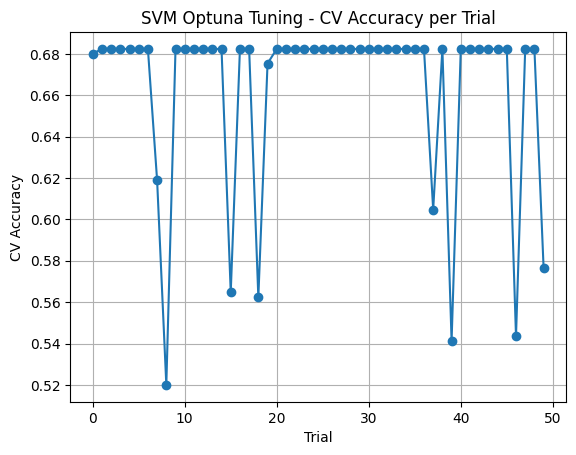


Best SVM Parameters:
  C: 0.012087541473056965
  gamma: scale
  kernel: poly
Best CV Accuracy: 0.6824


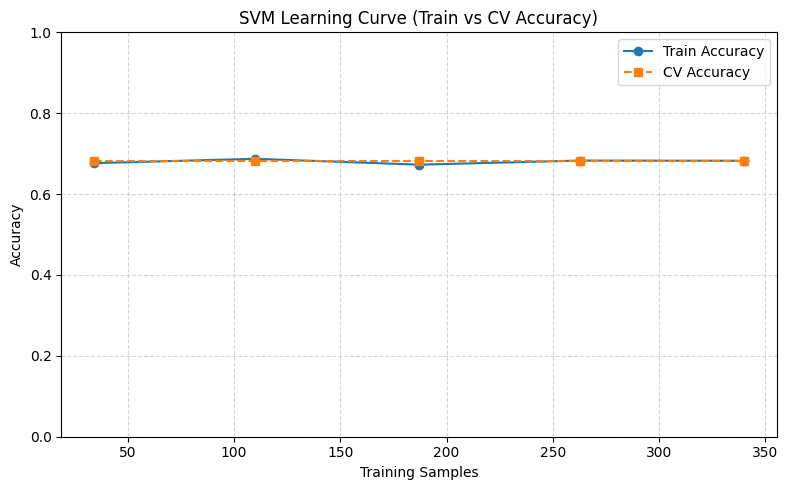


Final SVM TEST Metrics:
Accuracy : 0.6822
Precision: 0.2274
Recall   : 0.3333
F1-score : 0.2704

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.68      1.00      0.81        73
           2       0.00      0.00      0.00        12

    accuracy                           0.68       107
   macro avg       0.23      0.33      0.27       107
weighted avg       0.47      0.68      0.55       107



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

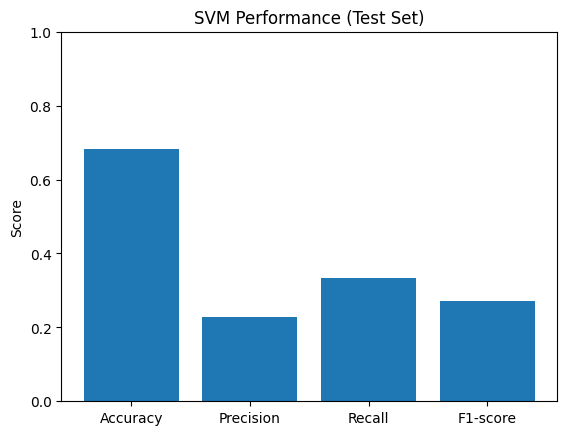

<Figure size 640x480 with 0 Axes>

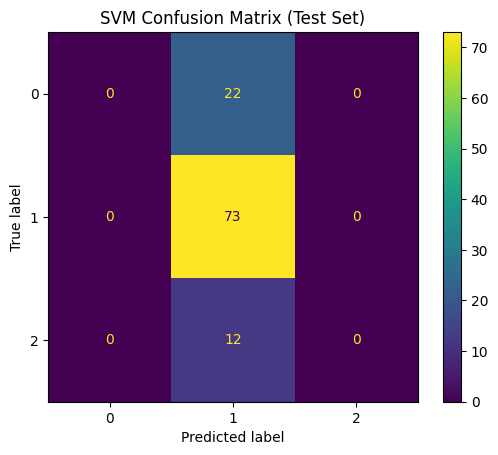

In [67]:
import optuna
from optuna.samplers import TPESampler

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve,      # 👈 নতুন ইমপোর্ট
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt
import numpy as np

# ===============================
#  1) Load / define your dataset
# ===============================
# X, y = your dataset
# X = ...
# y = ...

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ===============================
#  2) Optuna objective function (SVM)
# ===============================
def svm_objective(trial):

    # Hyperparameters to tune
    C = trial.suggest_float("C", 1e-2, 1e2, log=True)
    gamma = trial.suggest_categorical("gamma", ["scale", "auto", 0.1, 0.01, 0.001])
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid", "linear"])

    # Pipeline: StandardScaler + SVM
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "svm",
                SVC(
                    C=C,
                    gamma=gamma,
                    kernel=kernel,
                    random_state=42,
                    probability=True,
                ),
            ),
        ]
    )

    # 5-fold CV accuracy
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    return scores.mean()


# ===============================
#  3) Tuning + Metrics + Plots
# ===============================
def tune_svm(n_trials: int = 50):
    # Create study
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        study_name="svm_tuning",
    )
    study.optimize(svm_objective, n_trials=n_trials)

    # ----- Optuna "loss/accuracy curve" (CV accuracy per trial) -----
    trial_numbers = []
    trial_values = []

    for t in study.trials:
        if t.value is not None:
            trial_numbers.append(t.number)
            trial_values.append(t.value)

    plt.figure()
    plt.plot(trial_numbers, trial_values, marker="o")
    plt.title("SVM Optuna Tuning - CV Accuracy per Trial")
    plt.xlabel("Trial")
    plt.ylabel("CV Accuracy")
    plt.grid(True)
    plt.show()

    print("\nBest SVM Parameters:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    print(f"Best CV Accuracy: {study.best_value:.4f}")

    # ----- Train final model with best hyperparameters -----
    best_params = study.best_params

    final_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "svm",
                SVC(
                    **best_params,
                    random_state=42,
                    probability=True,
                ),
            ),
        ]
    )

    final_model.fit(X_train, y_train)

    # ======================================================
    # 🔥 NEW: Learning Curve (Train vs CV Accuracy) for SVM
    # ======================================================
    train_sizes, train_scores, val_scores = learning_curve(
        final_model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=42,
    )

    train_scores_mean = train_scores.mean(axis=1)
    val_scores_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores_mean, "o-", label="Train Accuracy")
    plt.plot(train_sizes, val_scores_mean, "s--", label="CV Accuracy")
    plt.title("SVM Learning Curve (Train vs CV Accuracy)")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----- TEST prediction -----
    preds = final_model.predict(X_test)

    # ----- Metrics (TEST) -----
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro")
    rec = recall_score(y_test, preds, average="macro")
    f1 = f1_score(y_test, preds, average="macro")

    print("\nFinal SVM TEST Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, preds))

    # ----- Bar plot of metrics -----
    metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
    values = [acc, prec, rec, f1]

    plt.figure()
    plt.bar(metrics, values)
    plt.ylim(0, 1)
    plt.title("SVM Performance (Test Set)")
    plt.ylabel("Score")
    plt.show()

    # ----- Confusion Matrix -----
    plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title("SVM Confusion Matrix (Test Set)")
    plt.show()

    return final_model, study


# ===============================
#  4) Main
# ===============================
if __name__ == "__main__":
    model, study = tune_svm(n_trials=50)


**Hyper parametr use of SVM and Gradiant Boosting.**

[I 2026-01-16 10:59:58,633] A new study created in memory with name: svm_tuning
[I 2026-01-16 10:59:58,800] Trial 0 finished with value: 0.6823529411764706 and parameters: {'C': 0.1767016940294795, 'kernel': 'rbf', 'gamma': 0.0006026889128682511, 'degree': 2}. Best is trial 0 with value: 0.6823529411764706.
[I 2026-01-16 10:59:58,945] Trial 1 finished with value: 0.6823529411764706 and parameters: {'C': 0.002231010801867922, 'kernel': 'rbf', 'gamma': 0.00012674255898937226, 'degree': 5}. Best is trial 0 with value: 0.6823529411764706.
[I 2026-01-16 10:59:59,319] Trial 2 finished with value: 0.6870588235294118 and parameters: {'C': 98.77700294007911, 'kernel': 'rbf', 'gamma': 0.0033205591037519565, 'degree': 4}. Best is trial 2 with value: 0.6870588235294118.
[I 2026-01-16 10:59:59,440] Trial 3 finished with value: 0.6823529411764706 and parameters: {'C': 0.3905441275210791, 'kernel': 'poly', 'gamma': 0.0028888383623653178, 'degree': 3}. Best is trial 2 with value: 0.6870588235294118.
[


Best SVM Params:
{'C': 122.63086167929075, 'kernel': 'rbf', 'gamma': 0.005387241441876549, 'degree': 2}
Best CV Accuracy: 0.6988


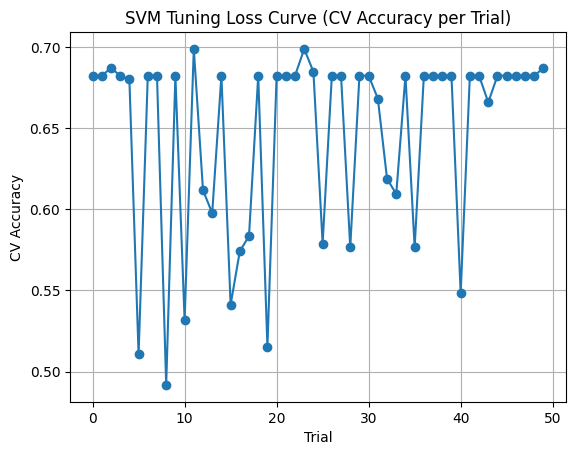


[SVM] TEST Metrics:
Accuracy : 0.7290
Precision: 0.8409
Recall   : 0.4596
F1-score : 0.4655

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.05      0.09        22
           1       0.72      1.00      0.84        73
           2       0.80      0.33      0.47        12

    accuracy                           0.73       107
   macro avg       0.84      0.46      0.47       107
weighted avg       0.79      0.73      0.64       107



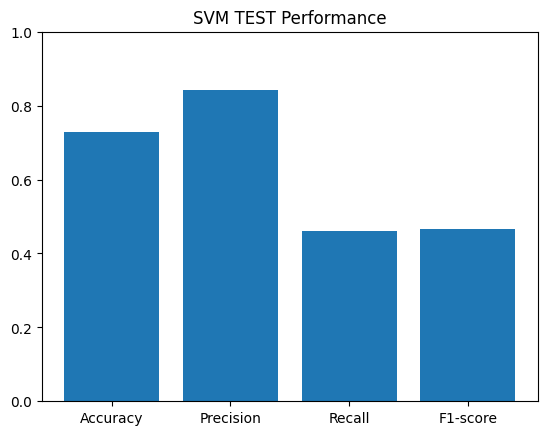

<Figure size 640x480 with 0 Axes>

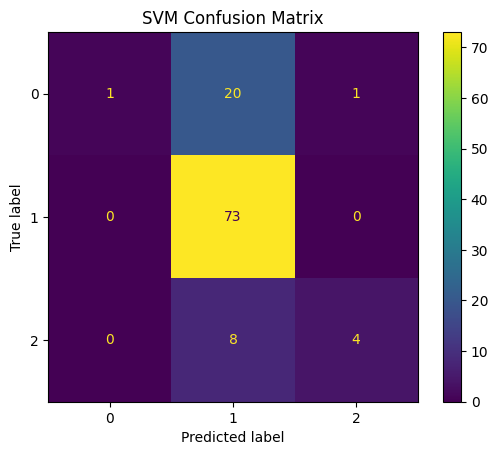

[I 2026-01-16 11:00:16,872] A new study created in memory with name: gb_tuning
[I 2026-01-16 11:00:25,443] Trial 0 finished with value: 0.6141176470588235 and parameters: {'n_estimators': 181, 'learning_rate': 0.28570714885887566, 'max_depth': 7, 'min_samples_split': 13, 'min_samples_leaf': 2, 'subsample': 0.5779972601681014}. Best is trial 0 with value: 0.6141176470588235.
[I 2026-01-16 11:00:29,218] Trial 1 finished with value: 0.6282352941176471 and parameters: {'n_estimators': 70, 'learning_rate': 0.2611910822747312, 'max_depth': 6, 'min_samples_split': 15, 'min_samples_leaf': 1, 'subsample': 0.9849549260809971}. Best is trial 1 with value: 0.6282352941176471.
[I 2026-01-16 11:00:39,044] Trial 2 finished with value: 0.6329411764705883 and parameters: {'n_estimators': 342, 'learning_rate': 0.07157834209670008, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 4, 'subsample': 0.762378215816119}. Best is trial 2 with value: 0.6329411764705883.
[I 2026-01-16 11:00:48,742] Tri


Best Gradient Boosting Params:
{'n_estimators': 65, 'learning_rate': 0.03574558603430181, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 10, 'subsample': 0.6941039695618896}
Best CV Accuracy: 0.7153


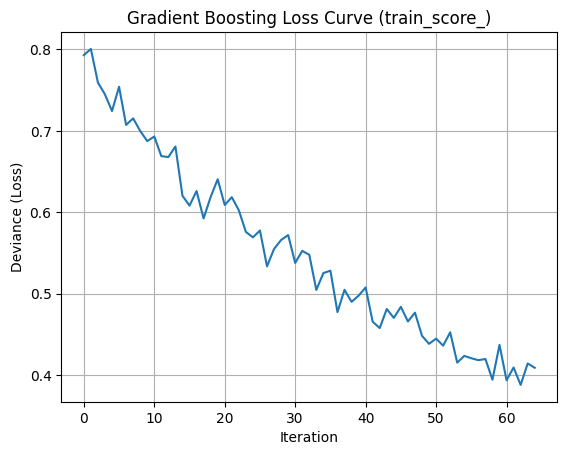


[Gradient Boosting] TEST Metrics:
Accuracy : 0.7290
Precision: 0.6380
Recall   : 0.4808
F1-score : 0.5013

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.14      0.21        22
           1       0.75      0.97      0.85        73
           2       0.67      0.33      0.44        12

    accuracy                           0.73       107
   macro avg       0.64      0.48      0.50       107
weighted avg       0.69      0.73      0.67       107



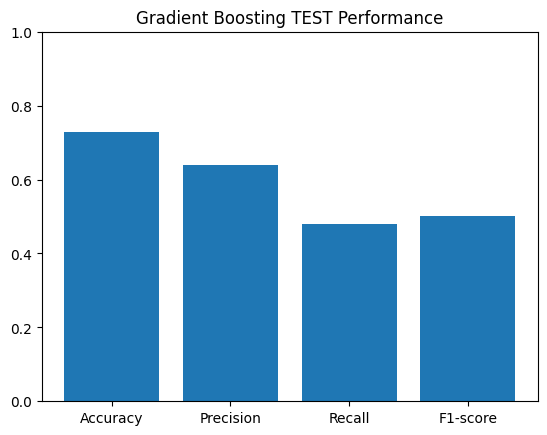

<Figure size 640x480 with 0 Axes>

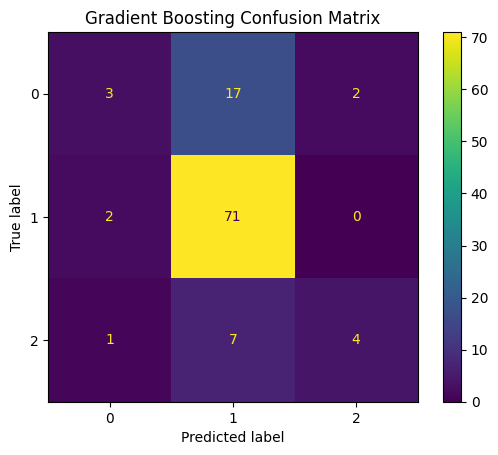

In [68]:
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# ===============================
# Load Dataset
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Metrics + Plots
# ===============================
def print_and_plot_metrics(y_true, y_pred, title_prefix="Model"):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n[{title_prefix}] TEST Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Bar Chart
    metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
    values = [acc, prec, rec, f1]

    plt.figure()
    plt.bar(metrics, values)
    plt.title(f"{title_prefix} TEST Performance")
    plt.ylim(0, 1)
    plt.show()

    # Confusion Matrix
    plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.show()


# ================================================
#  SVM — Optuna objective
# ================================================
def svm_objective(trial):

    C = trial.suggest_float("C", 1e-3, 1e3, log=True)
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"])
    gamma = trial.suggest_float("gamma", 1e-4, 1e1, log=True)
    degree = trial.suggest_int("degree", 2, 5)

    svm = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        degree=degree,
        probability=True,
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", svm),
    ])

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    return scores.mean()


def tune_svm(n_trials=50):

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        study_name="svm_tuning"
    )
    study.optimize(svm_objective, n_trials=n_trials)

    print("\nBest SVM Params:")
    print(study.best_params)
    print(f"Best CV Accuracy: {study.best_value:.4f}")

    # =========================
    # SVM LOSS CURVE (Optuna)
    # =========================
    trial_nums = [t.number for t in study.trials if t.value is not None]
    trial_scores = [t.value for t in study.trials if t.value is not None]

    plt.figure()
    plt.plot(trial_nums, trial_scores, marker="o")
    plt.title("SVM Tuning Loss Curve (CV Accuracy per Trial)")
    plt.xlabel("Trial")
    plt.ylabel("CV Accuracy")
    plt.grid(True)
    plt.show()

    # Final Model
    best = study.best_params
    svm = SVC(
        C=best["C"],
        kernel=best["kernel"],
        gamma=best["gamma"],
        degree=best["degree"],
        probability=True,
    )
    final_model = Pipeline([("scaler", StandardScaler()), ("svm", svm)])

    final_model.fit(X_train, y_train)
    preds = final_model.predict(X_test)

    print_and_plot_metrics(y_test, preds, "SVM")

    return final_model, study


# =======================================================
# Gradient Boosting — Optuna Objective
# =======================================================
def gb_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "random_state": 42,
    }

    model = GradientBoostingClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    return scores.mean()


def tune_gradient_boosting(n_trials=50):

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        study_name="gb_tuning"
    )
    study.optimize(gb_objective, n_trials=n_trials)

    print("\nBest Gradient Boosting Params:")
    print(study.best_params)
    print(f"Best CV Accuracy: {study.best_value:.4f}")

    # Final Model
    best = study.best_params
    final_model = GradientBoostingClassifier(**best, random_state=42)

    final_model.fit(X_train, y_train)

    # =========================
    # Gradient Boosting LOSS CURVE
    # =========================
    loss_curve = final_model.train_score_

    plt.figure()
    plt.plot(loss_curve)
    plt.title("Gradient Boosting Loss Curve (train_score_)")
    plt.xlabel("Iteration")
    plt.ylabel("Deviance (Loss)")
    plt.grid(True)
    plt.show()

    preds = final_model.predict(X_test)
    print_and_plot_metrics(y_test, preds, "Gradient Boosting")

    return final_model, study


# ===============================
# MAIN
# ===============================
if __name__ == "__main__":

    svm_model, svm_study = tune_svm(n_trials=50)

    gb_model, gb_study = tune_gradient_boosting(n_trials=50)


**Hypertuning of CATBoost,XGBoost**

[I 2026-01-16 11:05:30,649] A new study created in memory with name: xgboost_tuning
[I 2026-01-16 11:05:33,943] Trial 0 finished with value: 0.7035294117647058 and parameters: {'n_estimators': 181, 'max_depth': 10, 'learning_rate': 0.22227824312530747, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'min_child_weight': 1.5227525095137953, 'reg_lambda': 2.9154431891537547, 'reg_alpha': 0.2537815508265665}. Best is trial 0 with value: 0.7035294117647058.
[I 2026-01-16 11:05:34,371] Trial 1 finished with value: 0.6988235294117647 and parameters: {'n_estimators': 298, 'max_depth': 2, 'learning_rate': 0.29127385712697834, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'gamma': 0.9091248360355031, 'min_child_weight': 2.650640588680904, 'reg_lambda': 0.016480446427978974, 'reg_alpha': 0.12561043700013558}. Best is trial 0 with value: 0.7035294117647058.
[I 2026-01-16 11:05:34,718] Trial 2 finished with value: 0.69


[XGBoost] Best Parameters:
  n_estimators: 210
  max_depth: 4
  learning_rate: 0.03285432951322642
  subsample: 0.7433533875466022
  colsample_bytree: 0.6417611960525171
  gamma: 0.2378193533945948
  min_child_weight: 2.1549458520276286
  reg_lambda: 3.9500509016531637
  reg_alpha: 0.005528853766023211
[XGBoost] Best CV Accuracy: 0.7200


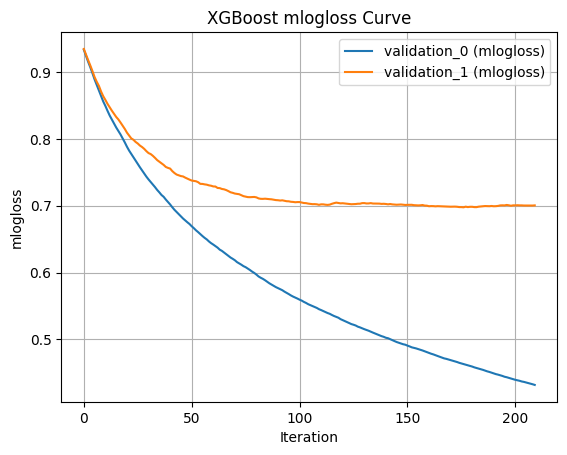


[XGBoost] TEST Metrics:
Accuracy : 0.7383
Precision: 0.7063
Recall   : 0.4959
F1-score : 0.5306

[XGBoost] Classification report:
              precision    recall  f1-score   support

           0       0.57      0.18      0.28        22
           1       0.75      0.97      0.85        73
           2       0.80      0.33      0.47        12

    accuracy                           0.74       107
   macro avg       0.71      0.50      0.53       107
weighted avg       0.72      0.74      0.69       107



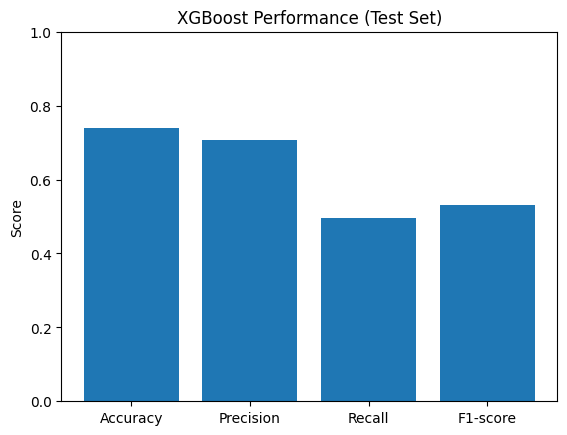

<Figure size 640x480 with 0 Axes>

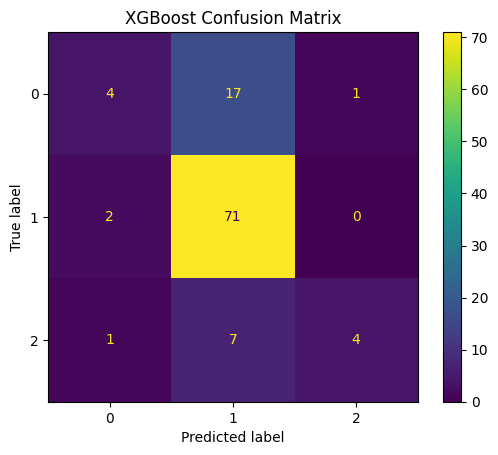

[I 2026-01-16 11:05:56,840] A new study created in memory with name: catboost_tuning
[I 2026-01-16 11:06:21,147] Trial 0 finished with value: 0.6729411764705883 and parameters: {'iterations': 287, 'depth': 10, 'learning_rate': 0.22227824312530747, 'l2_leaf_reg': 6.387926357773329, 'bagging_temperature': 0.7800932022121826, 'random_strength': 0.7799726016810132, 'border_count': 45}. Best is trial 0 with value: 0.6729411764705883.
[I 2026-01-16 11:06:32,303] Trial 1 finished with value: 0.6705882352941176 and parameters: {'iterations': 533, 'depth': 7, 'learning_rate': 0.21534104756085318, 'l2_leaf_reg': 1.185260448662222, 'bagging_temperature': 4.8495492608099715, 'random_strength': 4.162213204002109, 'border_count': 79}. Best is trial 0 with value: 0.6729411764705883.
[I 2026-01-16 11:06:33,331] Trial 2 finished with value: 0.7082352941176471 and parameters: {'iterations': 191, 'depth': 4, 'learning_rate': 0.09823025045826593, 'l2_leaf_reg': 5.72280788469014, 'bagging_temperature': 2.1


[CatBoost] Best Parameters:
  iterations: 421
  depth: 8
  learning_rate: 0.05052160509854926
  l2_leaf_reg: 9.539263123417506
  bagging_temperature: 2.694504274152476
  random_strength: 3.8223306282066893
  border_count: 90
[CatBoost] Best CV Accuracy: 0.7271


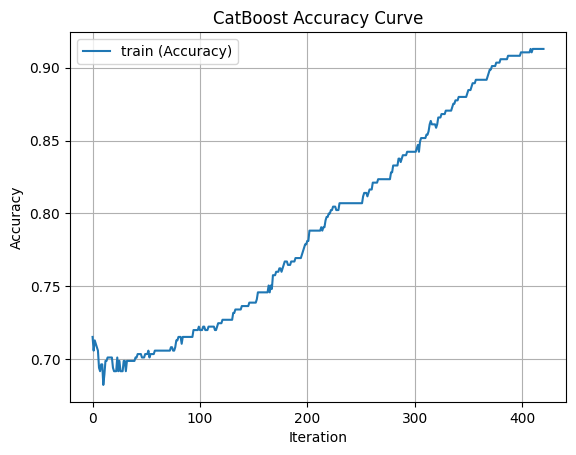


[CatBoost] TEST Metrics:
Accuracy : 0.7570
Precision: 0.7944
Recall   : 0.5156
F1-score : 0.5599

[CatBoost] Classification report:
              precision    recall  f1-score   support

           0       0.83      0.23      0.36        22
           1       0.75      0.99      0.85        73
           2       0.80      0.33      0.47        12

    accuracy                           0.76       107
   macro avg       0.79      0.52      0.56       107
weighted avg       0.77      0.76      0.71       107



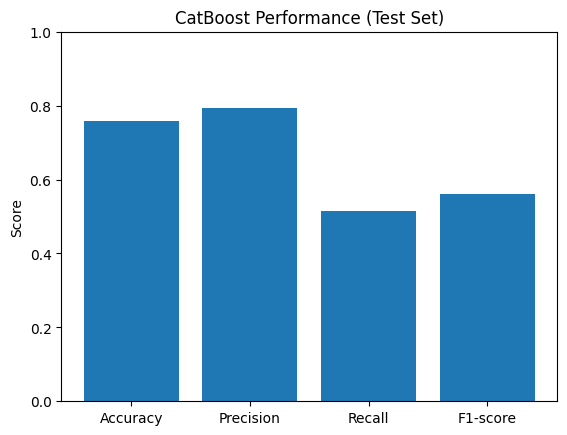

<Figure size 640x480 with 0 Axes>

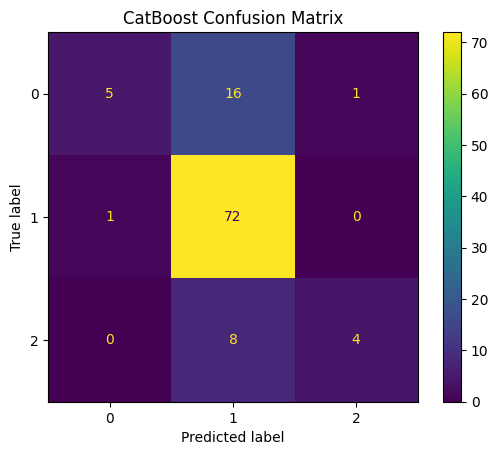

In [69]:
import optuna
from optuna.samplers import TPESampler

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# XGBoost / CatBoost
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ===============================
#  1) Load / define your dataset
# ===============================
# এখানে নিজের data বসাবে
# X = ...
# y = ...

# Example (demo) – নিজের ডেটা ব্যবহার করলে নিচের 2 লাইন মুছে দিও
# X = np.random.randn(1000, 20)
# y = np.random.randint(0, 3, size=1000)

# Train-test split (same for both models)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ==========================================
#  2) Common function: metrics + plots
# ==========================================
def print_and_plot_metrics(y_true, y_pred, title_prefix="Model"):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n[{title_prefix}] TEST Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print(f"\n[{title_prefix}] Classification report:")
    print(classification_report(y_true, y_pred))

    # Bar plot
    metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
    values = [acc, prec, rec, f1]

    plt.figure()
    plt.bar(metrics, values)
    plt.ylim(0, 1)
    plt.title(f"{title_prefix} Performance (Test Set)")
    plt.ylabel("Score")
    plt.show()

    # Confusion Matrix
    plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.show()

    return acc, prec, rec, f1


# ==========================================
#  2.1 Loss / metric curve helpers
# ==========================================
def plot_xgb_loss_curve(model, title_prefix="XGBoost"):
    """
    Plot training / validation metric curve from XGBoost evals_result_.
    """
    results = model.evals_result()
    # Usually keys: 'validation_0', 'validation_1', ...
    train_key = list(results.keys())[0]
    if len(results.keys()) > 1:
        valid_key = list(results.keys())[1]
    else:
        valid_key = None

    metric_name = list(results[train_key].keys())[0]

    train_metric = results[train_key][metric_name]
    plt.figure()
    plt.plot(train_metric, label=f"{train_key} ({metric_name})")

    if valid_key is not None:
        valid_metric = results[valid_key][metric_name]
        plt.plot(valid_metric, label=f"{valid_key} ({metric_name})")

    plt.xlabel("Iteration")
    plt.ylabel(metric_name)
    plt.title(f"{title_prefix} {metric_name} Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_catboost_loss_curve(model, title_prefix="CatBoost"):
    """
    Plot training / validation metric curve from CatBoost get_evals_result().
    """
    results = model.get_evals_result()
    # Typically 'learn' and 'validation_0'
    learn_key = "learn"
    learn_metrics = list(results[learn_key].keys())
    metric_name = learn_metrics[0]  # first metric

    train_metric = results[learn_key][metric_name]

    plt.figure()
    plt.plot(train_metric, label=f"train ({metric_name})")

    if "validation_0" in results:
        valid_metric = results["validation_0"][metric_name]
        plt.plot(valid_metric, label=f"valid ({metric_name})")

    plt.xlabel("Iteration")
    plt.ylabel(metric_name)
    plt.title(f"{title_prefix} {metric_name} Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


# ===============================================
#  3) XGBoost: Optuna objective + tuning + metrics
# ===============================================
def xgb_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "objective": "multi:softprob" if len(np.unique(y_train)) > 2 else "binary:logistic",
        "n_jobs": -1,
        "random_state": 42,
        "eval_metric": "mlogloss" if len(np.unique(y_train)) > 2 else "logloss",
        "use_label_encoder": False,
    }

    model = XGBClassifier(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="accuracy", n_jobs=-1
    )
    return scores.mean()


def tune_xgboost(n_trials: int = 50):
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        study_name="xgboost_tuning",
    )
    study.optimize(xgb_objective, n_trials=n_trials)

    print("\n[XGBoost] Best Parameters:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    print(f"[XGBoost] Best CV Accuracy: {study.best_value:.4f}")

    best_params = study.best_params
    best_params.update({
        "objective": "multi:softprob" if len(np.unique(y_train)) > 2 else "binary:logistic",
        "n_jobs": -1,
        "random_state": 42,
        "eval_metric": "mlogloss" if len(np.unique(y_train)) > 2 else "logloss",
        "use_label_encoder": False,
    })

    final_model = XGBClassifier(**best_params)

    # ===== Loss curve-এর জন্য eval_set যোগ করা =====
    final_model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False,
    )

    # XGBoost loss / metric curve
    plot_xgb_loss_curve(final_model, title_prefix="XGBoost")

    preds = final_model.predict(X_test)

    print_and_plot_metrics(y_test, preds, title_prefix="XGBoost")

    return final_model, study


# ===================================================
#  4) CatBoost: Optuna objective + tuning + metrics
# ===================================================
def catboost_objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 100, 600),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "MultiClass" if len(np.unique(y_train)) > 2 else "Logloss",
        "eval_metric": "Accuracy",
        "verbose": False,
        "random_state": 42,
    }

    model = CatBoostClassifier(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="accuracy", n_jobs=-1
    )
    return scores.mean()


def tune_catboost(n_trials: int = 50):
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        study_name="catboost_tuning",
    )
    study.optimize(catboost_objective, n_trials=n_trials)

    print("\n[CatBoost] Best Parameters:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    print(f"[CatBoost] Best CV Accuracy: {study.best_value:.4f}")

    best_params = study.best_params
    best_params.update({
        "loss_function": "MultiClass" if len(np.unique(y_train)) > 2 else "Logloss",
        "eval_metric": "Accuracy",
        "verbose": False,
        "random_state": 42,
    })

    final_model = CatBoostClassifier(**best_params)

    # ===== Loss curve-এর জন্য eval_set যোগ করা =====
    final_model.fit(
        X_train,
        y_train,
        eval_set=(X_test, y_test),
        use_best_model=False,
        verbose=False,
    )

    # CatBoost loss / metric curve
    plot_catboost_loss_curve(final_model, title_prefix="CatBoost")

    preds = final_model.predict(X_test)

    print_and_plot_metrics(y_test, preds, title_prefix="CatBoost")

    return final_model, study


# ===============================
#  5) Main
# ===============================
if __name__ == "__main__":
    xgb_model, xgb_study = tune_xgboost(n_trials=50)
    cat_model, cat_study = tune_catboost(n_trials=50)


**Create .pkl file**

In [70]:
# =========================
# FINAL PIPELINE (Preprocess + CatBoost) + SAVE
# Put this as the LAST CELL in your notebook
# =========================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) Target column name (change if needed)
TARGET_COL = "Sleep Disorder"

# 2) Basic checks
assert "df" in globals(), "❌ 'df' DataFrame পাওয়া যায়নি। আগে df = pd.read_csv(...) করে নাও।"
assert TARGET_COL in df.columns, f"❌ Target column '{TARGET_COL}' df-এ নাই। তোমার target কলামের নাম ঠিক করো।"

# 3) Split X/y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 4) Detect categorical & numeric columns (auto)
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("✅ Categorical cols:", cat_cols)
print("✅ Numeric cols:", num_cols)

# 5) Preprocessing pipelines
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# 6) Model (CatBoost)
cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

# 7) Full pipeline
pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", cat_model)
])

# 8) Train/test split (stratify চেষ্টা করবে যদি সম্ভব হয়)
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
except Exception:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

# 9) Train
pipeline.fit(X_train, y_train)

# 10) Quick evaluation
pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, pred)
print("\n✅ Test Accuracy:", round(acc, 4))
print("\n✅ Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("\n✅ Classification Report:\n", classification_report(y_test, pred))

# 11) Save pipeline
joblib.dump(pipeline, "sleep_disorder_pipeline.pkl")
print("\n✅ Saved: sleep_disorder_pipeline.pkl")





✅ Categorical cols: []
✅ Numeric cols: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

✅ Test Accuracy: 0.6449

✅ Confusion Matrix:
 [[ 3 18  1]
 [ 7 65  1]
 [ 1 10  1]]

✅ Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.14      0.18        22
           1       0.70      0.89      0.78        73
           2       0.33      0.08      0.13        12

    accuracy                           0.64       107
   macro avg       0.43      0.37      0.37       107
weighted avg       0.57      0.64      0.59       107


✅ Saved: sleep_disorder_pipeline.pkl


**New create .pkl file.**

In [71]:
# =========================
# FINAL RAW-DATA PIPELINE (OneHot + CatBoost) + SAVE
# =========================

import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

TARGET_COL = "Sleep Disorder"

# X / y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Auto-detect categorical & numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

# Pipelines
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)

# Quick check
pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

# Save
joblib.dump(pipeline, "sleep_disorder_pipeline.pkl")
print("✅ sleep_disorder_pipeline.pkl saved")


Categorical: []
Numeric: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']
Accuracy: 0.6448598130841121
✅ sleep_disorder_pipeline.pkl saved


In [72]:
from google.colab import files
files.download("sleep_disorder_pipeline.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>